# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# Run before imports in a fresh Colab runtime. PyTorch is supplied by Colab.
%pip -q install transformers==4.57.6 scikit-learn pandas matplotlib seaborn nltk lightgbm statsmodels tqdm joblib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 129.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from itertools import product, combinations
from collections import Counter

# ── Stats ────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── Other ML ─────────────────────────────────────────────
from lightgbm import LGBMClassifier
from scipy.sparse import hstack, csr_matrix
import joblib

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoConfig,
    AlbertForSequenceClassification,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Notebook setup ───────────────────────────────────────
# %matplotlib inline
warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

def require_finite_tensor(value, description):
    if not torch.isfinite(value).all():
        raise FloatingPointError(f"Non-finite {description}; no checkpoint or prediction will be selected.")

def require_finite_model(model):
    for name, value in model.state_dict().items():
        if value.is_floating_point():
            require_finite_tensor(value, f"model state {name}")

def require_probabilities(values, n_classes):
    values = np.asarray(values)
    if (values.ndim != 2 or values.shape[1] != n_classes or not np.isfinite(values).all()
            or (values < 0).any() or (values > 1).any()
            or not np.allclose(values.sum(axis=1), 1.0, atol=1e-5, rtol=1e-5)):
        raise ValueError("Invalid probability matrix.")
    return values

def checked_optimizer_step(loss, model, optimizer, scaler, max_norm, scheduler=None):
    require_finite_tensor(loss, "training loss")
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    grad_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(), max_norm, error_if_nonfinite=not scaler.is_enabled())
    previous_scale = scaler.get_scale()
    scaler.step(optimizer)
    scaler.update()
    updated = scaler.get_scale() >= previous_scale
    if updated and not torch.isfinite(grad_norm):
        raise FloatingPointError("Non-finite gradient norm without a skipped optimizer update.")
    if updated and scheduler is not None:
        scheduler.step()
    return updated

def save_transformer_record(model, tokenizer, params, name):
    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    require_finite_model(raw)
    record = {**params, **raw.training_record, "class_order": CLASS_NAMES,
              "pretrained_model": raw.config._name_or_path,
              "dropout_scope": ("classifier" if name == "albert" else "encoder_attention_and_classifier"),
              "effective_config": raw.config.to_dict(),
              "effective_dropout": {k: float(v.p) for k, v in raw.named_modules() if isinstance(v, nn.Dropout)},
              "tokenizer_class": type(tokenizer).__name__, "tokenizer_source": tokenizer.name_or_path}
    with open(MODEL_PATHS[name]["params"], "w") as stream:
        json.dump(record, stream, indent=2)
    raw.config.save_pretrained(OUTPUT_PATH / f"{name}_config")
    tokenizer.save_pretrained(OUTPUT_PATH / f"{name}_tokenizer")


## 1.2 Seeds \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

USE_FP16 = DEVICE.type == "cuda"
TORCH_COMPILE_OK = hasattr(torch, "compile") and DEVICE.type == "cuda"

Device: cuda


## 1.3 Configuration

In [7]:
# Complete baseline configuration. This cell also runs independently in a fresh kernel.
# Edit training settings here; no separate top-of-notebook setup is required.
import os
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/NLP_Projects/03_DrugReview")

DRIVE_PROJECT_PATH = str(PROJECT_ROOT / '02_4ominiLabel_aug')
# labels_v2 release, read where 00_labelling wrote it. The values below identify this exact release;
# the run stops if the file, the cohort size or the split differ.
RAW_DATA_FILE = "../00_labelling/output_v2/v2_ef356fdf87/drugscom_plus_ai_labels_v2_ef356fdf87.csv"
LABEL_RELEASE = {"protocol_id": "v2_ef356fdf87",
                 "label_file": "drugscom_plus_ai_labels_v2_ef356fdf87.csv",
                 "label_file_md5": "c22f6c05633214014db47c692e045ea1",
                 "split_fingerprint": "038e1d09a2818dfcf6a91dce49e35a22",
                 "n_eligible_both_streams": 102061}
SPLIT_FILE = "../00_split/data/DrugReview_split.csv"   # created once by 00_split, kept in its own folder
OUTPUT_DIR = "outputs"

TEXT_COLUMN0 = "review"
TEXT_COLUMN  = "model_text"
LABEL_COLUMN = "ai_sent5_hard"
LABEL_COLUMN_ENCODED = "sentiment_Encoded"
ID_COLUMN = "uniqueID"

# Explicit ordinal class order (NOT alphabetical)
CLASS_NAMES = ["VERY_NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "VERY_POSITIVE"]
NUM_CLASSES = len(CLASS_NAMES)

# Training settings
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
SEQ_MAX_GRAD_NORM = 5.0
MAX_GRAD_NORM = 1.0

# ── Model file paths ────────────────────────────────────
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
# (created after Drive is mounted, Section 1.4)

MODEL_PATHS = {
    "lr":      {"model": OUTPUT_PATH / "best_lr_model.joblib",   "params": OUTPUT_PATH / "best_lr_params.json"},
    "rf":      {"model": OUTPUT_PATH / "best_rf_model.joblib",   "params": OUTPUT_PATH / "best_rf_params.json"},
    "lgbm":    {"model": OUTPUT_PATH / "best_lgbm_model.joblib", "params": OUTPUT_PATH / "best_lgbm_params.json"},
    "gru":     {"model": OUTPUT_PATH / "best_gru_model.pth",     "params": OUTPUT_PATH / "best_gru_params.json"},
    "cnn":     {"model": OUTPUT_PATH / "best_cnn_model.pth",     "params": OUTPUT_PATH / "best_cnn_params.json"},
    "albert":  {"model": OUTPUT_PATH / "best_albert_model.pth",  "params": OUTPUT_PATH / "best_albert_params.json"},
    "biobert": {"model": OUTPUT_PATH / "best_biobert_model.pth", "params": OUTPUT_PATH / "best_biobert_params.json"},
}

RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)
SPLIT_PATH = os.path.join(DRIVE_PROJECT_PATH, SPLIT_FILE)

print("--- Configuration Loaded ---")
print(f"  Project : {DRIVE_PROJECT_PATH}")
print(f"  Classes : {CLASS_NAMES}")
print(f"  Trials  : {N_ITERATIONS}")


--- Configuration Loaded ---
  Project : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug
  Classes : ['VERY_NEGATIVE', 'NEGATIVE', 'NEUTRAL', 'POSITIVE', 'VERY_POSITIVE']
  Trials  : 10


## 1.4 Load the data

In [8]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# ── Label release: the file pinned in the configuration cell, verified before it is used ──
import hashlib
_h = hashlib.md5()
with open(RAW_DATA_PATH, "rb") as _f:
    for _chunk in iter(lambda: _f.read(1 << 24), b""):
        _h.update(_chunk)
assert _h.hexdigest() == LABEL_RELEASE["label_file_md5"], f"This is not the labels_v2 file pinned in the configuration cell (md5 {_h.hexdigest()})."
print("Label release:", LABEL_RELEASE["protocol_id"], "|", LABEL_RELEASE["label_file"])

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0).reset_index()   # keep uniqueID as a column
RELEASE_IDS = set(df_raw[ID_COLUMN])          # the complete release; compared with the split file in Section 1.7

# One cohort for every target (rating, holistic, fused): reviews with a valid holistic AND a valid aspect
# annotation. A failed annotation is never turned into NEUTRAL - the review is left out of every notebook.
assert df_raw["eligible_both_streams"].isin([True, False]).all()
df_raw = df_raw[df_raw["eligible_both_streams"].astype(bool)].reset_index(drop=True)
assert len(df_raw) == LABEL_RELEASE["n_eligible_both_streams"]
COHORT_FINGERPRINT = hashlib.md5("|".join(sorted(df_raw[ID_COLUMN].astype(str))).encode()).hexdigest()
print(f"Eligible cohort: {len(df_raw)} of {len(RELEASE_IDS)} reviews | cohort fingerprint {COHORT_FINGERPRINT}")
assert ID_COLUMN in df_raw.columns and df_raw[ID_COLUMN].is_unique
print(f"Loaded {df_raw.shape[0]} rows.")

df_raw.head()

Mounted at /content/drive/
Label release: v2_ef356fdf87 | drugscom_plus_ai_labels_v2_ef356fdf87.csv
Eligible cohort: 102061 of 102061 reviews | cohort fingerprint a958bfd33bc42e981e63aef1054f8ca3
Loaded 102061 rows.


# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [9]:
# The holistic five-class target is read directly from LABEL_COLUMN in the frozen release.


In [10]:
df_raw["ingredient_set_key"] = (df_raw["ingredient_set_key"].fillna("")
                                .astype(str).str.lower().str.strip()
                                .str.replace(r"\s+", " ", regex=True))
df_raw["condition_norm"] = (df_raw["condition_norm"].fillna("")
                            .astype(str).str.lower().str.strip()
                            .str.replace(r"\s+", " ", regex=True))
df_raw["n_ingredients"] = pd.to_numeric(df_raw["n_ingredients"], errors="coerce").fillna(0).astype(int)

# Keep needed columns
df_raw = df_raw[[ID_COLUMN, TEXT_COLUMN0, LABEL_COLUMN, "n_ingredients", "ingredient_set_key", "condition_norm"]]

In [11]:
def build_model_text(r):
    return (f"[COND] {r['condition_norm']} "
            f"[ING] {r['ingredient_set_key']} "
            f"[N_ING] {r['n_ingredients']} "
            f"[TEXT] {r[TEXT_COLUMN0]}")

df_raw[TEXT_COLUMN] = df_raw.apply(build_model_text, axis=1)

print(f"\n{LABEL_COLUMN} distribution:")
print(df_raw[LABEL_COLUMN].value_counts())


ai_sent5_hard distribution:
ai_sent5_hard
VERY_POSITIVE    32399
POSITIVE         30762
VERY_NEGATIVE    18487
NEGATIVE         17136
NEUTRAL           3277
Name: count, dtype: int64


In [12]:
# Shuffle
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)
df_raw

,uniqueID,review,ai_sent5_hard,n_ingredients,ingredient_set_key,condition_norm,model_text
0,202160,"I was never one to have severe acne, just a fe...",VERY_POSITIVE,2,benzoyl peroxide / clindamycin,acne,[COND] acne [ING] benzoyl peroxide / clindamyc...
1,109541,I've had the Nexplanon since May 2015.I got it...,NEGATIVE,1,etonogestrel,birth control,[COND] birth control [ING] etonogestrel [N_ING...
2,160870,I have been taking Buspar for just over 8 mont...,VERY_POSITIVE,1,buspirone,anxiety,[COND] anxiety [ING] buspirone [N_ING] 1 [TEXT...
3,160358,I've been on this for two weeks. I went to my ...,VERY_POSITIVE,1,buspirone,anxiety,[COND] anxiety [ING] buspirone [N_ING] 1 [TEXT...
4,82249,I Love this medication!!! My blood sugar staye...,POSITIVE,1,liraglutide,"diabetes, type 2","[COND] diabetes, type 2 [ING] liraglutide [N_I..."
...,...,...,...,...,...,...,...
102056,79327,My lover and I had unprotected sex on 12/26 wh...,POSITIVE,1,levonorgestrel,emergency contraception,[COND] emergency contraception [ING] levonorge...
102057,57269,Great for relief of back pain BUT severe side ...,NEGATIVE,2,esomeprazole / naproxen,osteoarthritis,[COND] osteoarthritis [ING] esomeprazole / nap...
102058,26014,I am a 30 year old female who has had eczema m...,POSITIVE,1,dupilumab,eczema,[COND] eczema [ING] dupilumab [N_ING] 1 [TEXT]...
102059,196612,Used for 4.6years. Experienced many common si...,POSITIVE,1,letrozole,breast cance,[COND] breast cance [ING] letrozole [N_ING] 1 ...


## 2.2 Master Data Preparation

In [13]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [14]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(CLASS_NAMES)  # force ordinal order
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.transform(df_clean[LABEL_COLUMN])

print(f"Label mapping: {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}")
print(f"df_clean: {df_clean.shape[0]} rows")


Label mapping: {'VERY_NEGATIVE': 0, 'NEGATIVE': 1, 'NEUTRAL': 2, 'POSITIVE': 3, 'VERY_POSITIVE': 4}
df_clean: 102061 rows


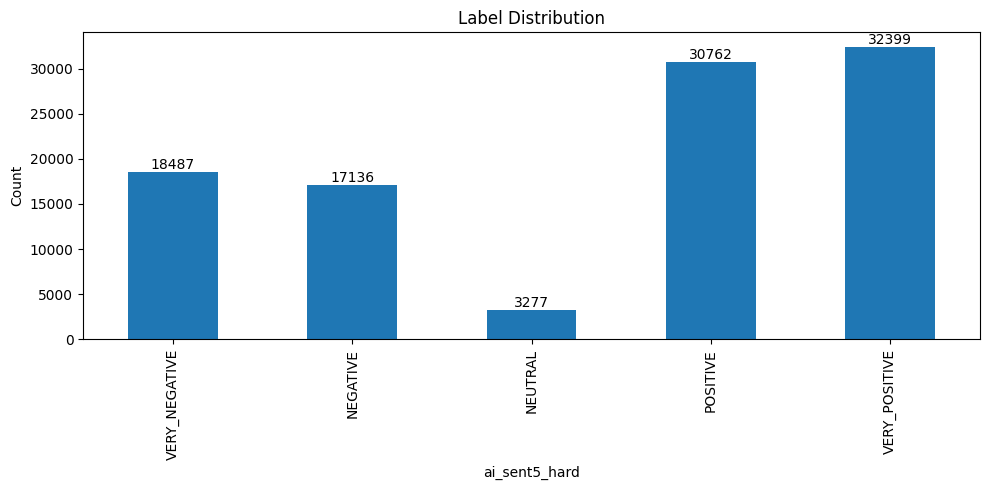

In [15]:
plt.figure(figsize=(10, 5))
counts = df_clean[LABEL_COLUMN].value_counts().reindex(CLASS_NAMES)
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Label Distribution")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

In [16]:
import sys
# group on the review narrative, not on the metadata-augmented model input
df_clean["group_text"] = df_clean[TEXT_COLUMN0].apply(clean_text)
GROUP_COLUMN = "group_text"
# ── Shared split: created once by 00_split, never recomputed here ─────────
import hashlib
manifest = pd.read_csv(SPLIT_PATH)
assert manifest[ID_COLUMN].is_unique, "split file: duplicate IDs"
_missing = RELEASE_IDS - set(manifest[ID_COLUMN])          # checked on the complete release, not on the cohort
_extra   = set(manifest[ID_COLUMN]) - RELEASE_IDS
assert not _missing and not _extra, (
    f"Split file and data disagree: {len(_missing)} rows without a split, {len(_extra)} split rows "
    "without data. Do not recompute a split here - rerun 00_split.")
# the label file carries its own "split" column (Drugs.com train/test origin); the manifest replaces it
df_clean = df_clean.drop(columns=[c for c in manifest.columns if c != ID_COLUMN and c in df_clean.columns])
df_clean = df_clean.merge(manifest, on=ID_COLUMN, how="left", validate="one_to_one")

SPLIT_FINGERPRINT = hashlib.md5(
    "|".join(f"{u}:{s}" for u, s in sorted(zip(manifest[ID_COLUMN].astype(str), manifest["split"]))).encode()
).hexdigest()
print("Split fingerprint:", SPLIT_FINGERPRINT, "(identical in every notebook and in 00_split)")
assert SPLIT_FINGERPRINT == LABEL_RELEASE["split_fingerprint"], "The labels were released under a different split."

# split == "audit": the 500 human-annotated reviews plus every row sharing a narrative with one of
# them. They are never trained, validated or fitted on; they are predicted separately
# (Sections 3.4 and 4.3) and reported separately from the ordinary test set.

print("Split counts:")
print(df_clean["split"].value_counts())

# Leakage check
n_leaky = (df_clean.groupby("narrative_group")["split"].nunique() > 1).sum()
assert n_leaky == 0, f"{n_leaky} narratives leak across splits!"
assert not df_clean.loc[df_clean["is_audit_group"], "split"].isin(["train", "val", "test"]).any()
print(f"Leakage check passed.")

print("Split proportions:")
print(df_clean["split"].value_counts(normalize=True))

# Save master split
split_path = OUTPUT_PATH / "DrugReview_master_split.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")

# ── Provenance saved with the outputs ───────────────────────────────────
import sklearn, transformers
RUN_INFO = {
    "label_column": LABEL_COLUMN, "class_order": CLASS_NAMES, "split_fingerprint": SPLIT_FINGERPRINT,
    "label_release": LABEL_RELEASE["protocol_id"], "label_file": LABEL_RELEASE["label_file"], "label_file_md5": LABEL_RELEASE["label_file_md5"],
    "cohort_fingerprint": COHORT_FINGERPRINT, "n_release": len(RELEASE_IDS),
    "n_rows": int(len(df_clean)), "split_counts": df_clean["split"].value_counts().to_dict(),
    "seed": SEED, "random_state": RANDOM_STATE, "max_token_length": MAX_TOKEN_LENGTH,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__,
    "sklearn": sklearn.__version__, "torch": torch.__version__, "transformers": transformers.__version__,
}
with open(OUTPUT_PATH / "run_info.json", "w") as _f:
    json.dump(RUN_INFO, _f, indent=2)
print(RUN_INFO)


Split fingerprint: 038e1d09a2818dfcf6a91dce49e35a22 (identical in every notebook and in 00_split)
Split counts:
split
train    60950
test     20298
val      20256
audit      557
Name: count, dtype: int64
Leakage check passed.
Split proportions:
split
train    0.597192
test     0.198881
val      0.198470
audit    0.005458
Name: proportion, dtype: float64
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/DrugReview_master_split.csv
{'label_column': 'ai_sent5_hard', 'class_order': ['VERY_NEGATIVE', 'NEGATIVE', 'NEUTRAL', 'POSITIVE', 'VERY_POSITIVE'], 'split_fingerprint': '038e1d09a2818dfcf6a91dce49e35a22', 'label_release': 'v2_ef356fdf87', 'label_file': 'drugscom_plus_ai_labels_v2_ef356fdf87.csv', 'label_file_md5': 'c22f6c05633214014db47c692e045ea1', 'cohort_fingerprint': 'a958bfd33bc42e981e63aef1054f8ca3', 'n_release': 102061, 'n_rows': 102061, 'split_counts': {'train': 60950, 'test': 20298, 'val': 20256, 'audit': 557}, 'seed': 2025, 'random_state': 42,

## 2.4 Shared helper functions

### 2.4.1 Bootstrap CI

In [17]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    """Return the OBSERVED F1 on the full test set plus a bootstrap 95% CI.

    The first element is the direct point estimate, not the mean of the
    bootstrap replicates; replicates are used only for the interval.
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    observed = f1_score(y_true, y_pred, average=average)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return observed, np.nan, np.nan
    return observed, np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    """Observed macro AUC plus a bootstrap 95% CI (point estimate is direct)."""
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    try:
        observed = roc_auc_score(y_true, y_scores, average=average, multi_class="ovr")
    except Exception:
        observed = np.nan
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return observed, np.nan, np.nan
    return observed, np.percentile(scores, 2.5), np.percentile(scores, 97.5)

### 2.4.2 Plotting

In [18]:
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes_list, title="Model", save_dir=None):
    """Works for both string and int class lists."""
    y_true_bin = label_binarize(y_true, classes=classes_list)
    n_classes = len(classes_list)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (cls, color) in enumerate(zip(classes_list, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{cls} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

### 2.4.3 Machine Learning Evaluation Wrapper

In [19]:
def evaluate_ml(model, X_test, y_test, model_name="Model"):
    """Full evaluation for a fitted sklearn classifier."""
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)
    classes = model.classes_

    print(classification_report(y_test, y_pred, digits=4, labels=classes))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_test, y_pred)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    f1_mac, f1_mac_lo, f1_mac_hi = bootstrap_f1_ci(y_test, y_pred, average="macro")
    print(f"Macro F1:    {f1_mac:.4f}  95% CI [{f1_mac_lo:.4f}, {f1_mac_hi:.4f}]")
    f1_mic, f1_mic_lo, f1_mic_hi = bootstrap_f1_ci(y_test, y_pred, average="micro")
    print(f"Micro F1:    {f1_mic:.4f}  95% CI [{f1_mic_lo:.4f}, {f1_mic_hi:.4f}]  (= accuracy)")

    plot_confusion_matrix(y_test, y_pred, labels=classes,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("No probability scores available.")
        return

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_scores)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(y_test, y_scores, classes,
                       title=model_name, save_dir=str(OUTPUT_PATH))

### 2.4.4 PyTorch Evaluation Wrapper

In [20]:
@torch.no_grad()
def evaluate_pytorch(model, test_loader, label_encoder, model_name="Model",
                     use_attention_mask=True):
    """Full evaluation for a PyTorch classifier."""
    model.eval().to(DEVICE)
    all_preds, all_probs, all_labels = [], [], []

    for batch in tqdm(test_loader, desc=f"Eval {model_name}"):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if use_attention_mask:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
        else:
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        require_finite_tensor(logits, "evaluation logits")
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = require_probabilities(np.array(all_probs), NUM_CLASSES)
    classes_str = label_encoder.classes_
    classes_int = np.arange(NUM_CLASSES)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    print(classification_report(all_labels, all_preds,
                                target_names=classes_str, digits=4))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(all_labels, all_preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(all_labels, all_preds, labels=classes_int,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(all_labels, all_probs)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(all_labels, all_probs, classes_int,
                       title=model_name, save_dir=str(OUTPUT_PATH))

    return all_preds, all_probs, all_labels

### 2.4.5 Machine Learning Feature Importance (shared)

In [21]:

def plot_feature_importance(importances, feature_names, model_name="Model", top_n=20):
    """Generic feature importance plot for any ML model."""
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp["Scaled"] = (df_imp["Importance"] / df_imp["Importance"].max()) * 100
    top = df_imp.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x="Scaled", y="Feature", data=top[::-1], palette="mako")
    plt.title(f"Top {top_n} Feature Importance ({model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Relative Importance (%)")
    plt.ylabel("Feature")
    plt.tight_layout()

    path = OUTPUT_PATH / f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    plt.savefig(path, dpi=300)
    print(f"Saved → {path}")
    plt.show()

    return top

# 3. Classical ML Modeling

## 3.0 Pre-processing for classical ML Models


In [22]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def ml_preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(tokens)


df_ml = df_clean.copy()
# 1) Base text feature: the cleaned review, exactly as in the text-only notebooks
df_ml["text_ml"] = df_ml["group_text"].apply(ml_preprocess)

# 2) Condition feature
if "condition_norm" in df_ml.columns:
    df_ml["condition_ml"] = df_ml["condition_norm"].fillna("").astype(str).apply(ml_preprocess)
else:
    df_ml["condition_ml"] = ""

# 3) Ingredient feature
ing_col = next((c for c in ["ingredient_set_key", "ingredient_norm"] if c in df_ml.columns), None)
if ing_col:
    df_ml["ingredient_ml"] = df_ml[ing_col].fillna("").astype(str).apply(ml_preprocess)
else:
    df_ml["ingredient_ml"] = ""

# 4) Numeric: n_ingredients (capped at 5)
if "n_ingredients" in df_ml.columns:
    df_ml["n_ingredients_capped"] = df_ml["n_ingredients"].fillna(0).astype(float).clip(0, 5)
else:
    df_ml["n_ingredients_capped"] = 0.0

print("ML features: text_ml, condition_ml, ingredient_ml, n_ingredients_capped")

# ── Splits ───────────────────────────────────────────────
df_train_ml = df_ml[df_ml["split"] == "train"].copy()
df_val_ml   = df_ml[df_ml["split"] == "val"].copy()
df_test_ml  = df_ml[df_ml["split"] == "test"].copy()

y_train_ml = df_train_ml[LABEL_COLUMN].astype(str).values
y_val_ml   = df_val_ml[LABEL_COLUMN].astype(str).values
y_test_ml  = df_test_ml[LABEL_COLUMN].astype(str).values

def safe_str(s): return s.fillna("").astype(str).values

# ── TF-IDF vectorizers (fit on TRAIN only) ───────────────
tfidf_text = TfidfVectorizer(max_features=10000)
tfidf_cond = TfidfVectorizer(max_features=2000)
tfidf_ing  = TfidfVectorizer(max_features=2000)

X_train_text_tf = tfidf_text.fit_transform(safe_str(df_train_ml["text_ml"]))
X_val_text_tf   = tfidf_text.transform(safe_str(df_val_ml["text_ml"]))
X_test_text_tf  = tfidf_text.transform(safe_str(df_test_ml["text_ml"]))

X_train_cond_tf = tfidf_cond.fit_transform(safe_str(df_train_ml["condition_ml"]))
X_val_cond_tf   = tfidf_cond.transform(safe_str(df_val_ml["condition_ml"]))
X_test_cond_tf  = tfidf_cond.transform(safe_str(df_test_ml["condition_ml"]))

X_train_ing_tf  = tfidf_ing.fit_transform(safe_str(df_train_ml["ingredient_ml"]))
X_val_ing_tf    = tfidf_ing.transform(safe_str(df_val_ml["ingredient_ml"]))
X_test_ing_tf   = tfidf_ing.transform(safe_str(df_test_ml["ingredient_ml"]))

# Numeric → sparse
n_train = csr_matrix(df_train_ml["n_ingredients_capped"].values.reshape(-1, 1))
n_val   = csr_matrix(df_val_ml["n_ingredients_capped"].values.reshape(-1, 1))
n_test  = csr_matrix(df_test_ml["n_ingredients_capped"].values.reshape(-1, 1))

# ── Stack all features ───────────────────────────────────
X_train_tfidf = hstack([X_train_text_tf, X_train_cond_tf, X_train_ing_tf, n_train], format="csr")
X_val_tfidf   = hstack([X_val_text_tf,   X_val_cond_tf,   X_val_ing_tf,   n_val],   format="csr")
X_test_tfidf  = hstack([X_test_text_tf,  X_test_cond_tf,  X_test_ing_tf,  n_test],  format="csr")

print(f"ML features: train={X_train_tfidf.shape}, val={X_val_tfidf.shape}, test={X_test_tfidf.shape}")
feature_names_tfidf = np.concatenate([
    tfidf_text.get_feature_names_out(),
    np.char.add("cond_", tfidf_cond.get_feature_names_out()),
    np.char.add("ing_", tfidf_ing.get_feature_names_out()),
    np.array(["n_ingredients"]),
])

print(f"ML splits: train={len(df_train_ml)}, val={len(df_val_ml)}, test={len(df_test_ml)}")

joblib.dump({"text": tfidf_text, "condition": tfidf_cond, "ingredient": tfidf_ing},
            OUTPUT_PATH / "tfidf_vectorizers.joblib")


ML features: text_ml, condition_ml, ingredient_ml, n_ingredients_capped
ML features: train=(60950, 11941), val=(20256, 11941), test=(20298, 11941)
ML splits: train=60950, val=20256, test=20298


['/content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/tfidf_vectorizers.joblib']

## 3.1 Logistic Regression

### Step 1: Hyperparameter Tuning

In [23]:
RETRAIN = True
if RETRAIN:
    # 7.1 Hyperparameter Tuning (grid search)
    set_seed()
    print("Tuning Logistic Regression...")
    start = time.time()

    lr_grid = {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
        "class_weight": ["balanced", None],
    }

    best_f1_lr, best_model_lr, best_params_lr = 0, None, None

    for C, solver, cw in product(lr_grid["C"], lr_grid["solver"], lr_grid["class_weight"]):
        try:
            model = LogisticRegression(
                C=C, solver=solver, penalty="l2",
                class_weight=cw, max_iter=1000, random_state=RANDOM_STATE,
                n_jobs=-1 if solver == "saga" else None,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lr:
                best_f1_lr = f1
                best_model_lr = model
                best_params_lr = {"C": C, "solver": solver, "class_weight": cw}
                print(f"  LR F1={f1:.4f} | {best_params_lr}")
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LR tuning: {time.time()-start:.1f}s | Best F1={best_f1_lr:.4f}")

    if best_model_lr is None:
        raise RuntimeError("No logistic regression candidate could be fitted - see the 'Skipped' messages above.")
    joblib.dump(best_model_lr, MODEL_PATHS["lr"]["model"])
    with open(MODEL_PATHS["lr"]["params"], "w") as f:
        json.dump(best_params_lr, f, indent=2)
else:
    print("Loading LR from disk...")
    best_model_lr = joblib.load(MODEL_PATHS["lr"]["model"])
    print(f"Loaded LR from {MODEL_PATHS['lr']['model']}")

Tuning Logistic Regression...
  LR F1=0.5352 | {'C': 0.1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.5605 | {'C': 0.1, 'solver': 'lbfgs', 'class_weight': None}
  LR F1=0.5695 | {'C': 1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.5874 | {'C': 1, 'solver': 'lbfgs', 'class_weight': None}
  LR F1=0.5877 | {'C': 1, 'solver': 'saga', 'class_weight': None}
LR tuning: 637.3s | Best F1=0.5877


### Step 2: Model Evaluation


Evaluation: Logistic_Regression
               precision    recall  f1-score   support

     NEGATIVE     0.4731    0.3502    0.4025      3461
      NEUTRAL     0.1579    0.0094    0.0178       637
     POSITIVE     0.5386    0.6190    0.5760      6090
VERY_NEGATIVE     0.6798    0.7013    0.6904      3653
VERY_POSITIVE     0.6955    0.7463    0.7200      6457

     accuracy                         0.6094     20298
    macro avg     0.5090    0.4853    0.4813     20298
 weighted avg     0.5908    0.6094    0.5953     20298

Weighted F1: 0.5953  95% CI [0.5879, 0.6018]
Macro F1:    0.4813  95% CI [0.4756, 0.4873]
Micro F1:    0.6094  95% CI [0.6027, 0.6158]  (= accuracy)
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/Logistic_Regression_confusion_matrix.png


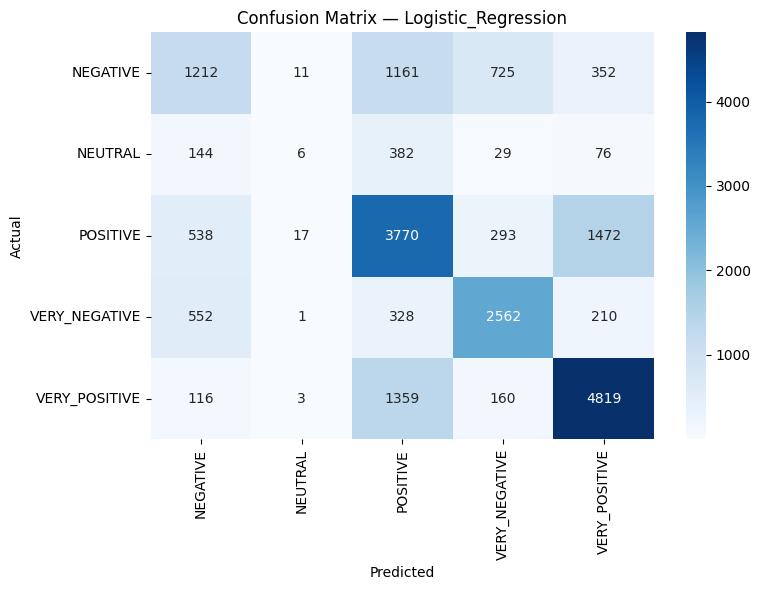

Macro AUC: 0.8344  95% CI [0.8300, 0.8393]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/Logistic_Regression_roc_curve.png


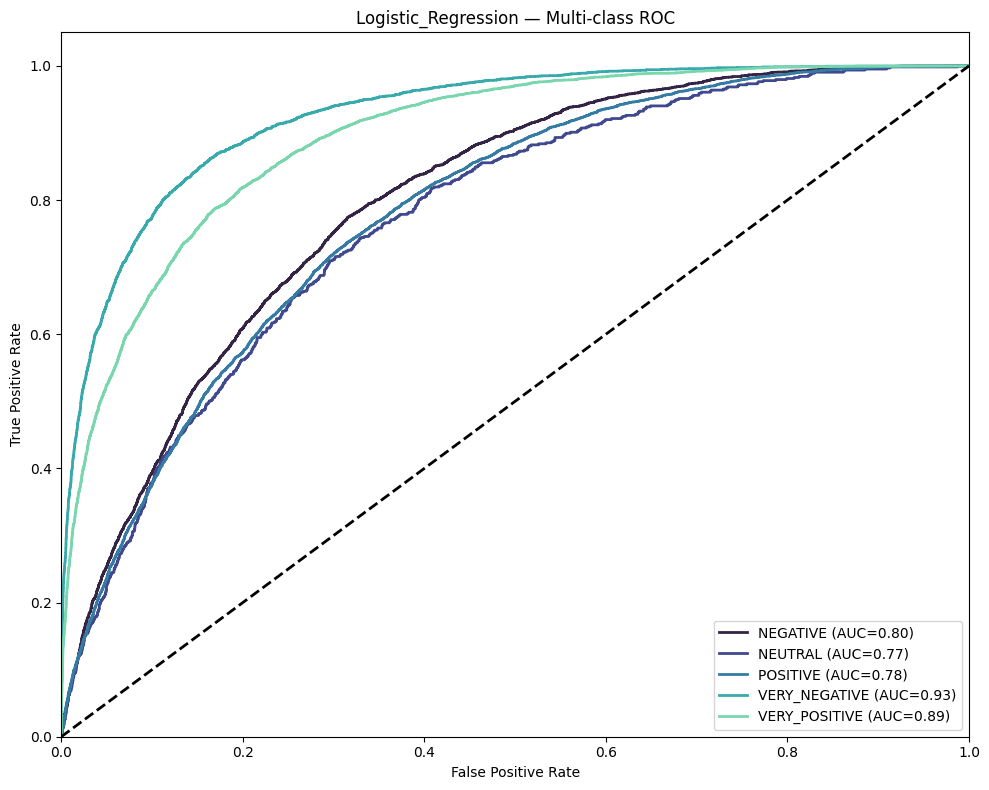

In [24]:
evaluate_ml(best_model_lr, X_test_tfidf, y_test_ml, "Logistic_Regression")

### Step 3: Model Interpretation

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/logistic_regression_feature_importance.png


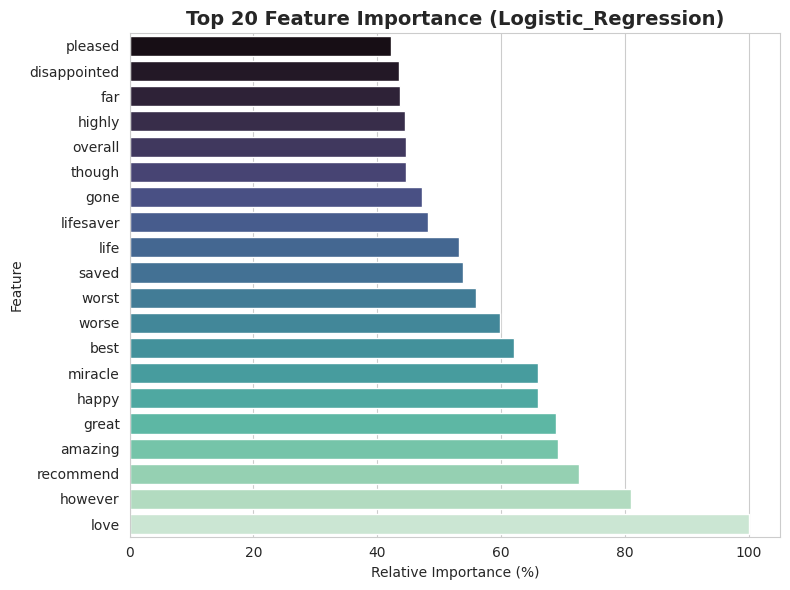

In [25]:
if hasattr(best_model_lr, "coef_"):
    importances_lr = np.abs(best_model_lr.coef_).mean(axis=0) if best_model_lr.coef_.shape[0] > 1 else np.abs(best_model_lr.coef_[0])
    plot_feature_importance(importances_lr, feature_names_tfidf, "Logistic_Regression")

## 3.2 Random Forest

### Step 1: Hyperparameter Tuning

In [26]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning Random Forest...")
    start = time.time()

    rf_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": ["balanced", None],
    }

    best_f1_rf, best_model_rf, best_params_rf = 0, None, None

    for n_est, md, mss, msl, cw in tqdm(
        list(product(rf_grid["n_estimators"], rf_grid["max_depth"],
                     rf_grid["min_samples_split"], rf_grid["min_samples_leaf"],
                     rf_grid["class_weight"])),
        desc="RF grid"
    ):
        try:
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=md, min_samples_split=mss,
                min_samples_leaf=msl, class_weight=cw,
                random_state=RANDOM_STATE, n_jobs=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_rf:
                best_f1_rf = f1
                best_model_rf = model
                best_params_rf = {"n_estimators": n_est, "max_depth": md,
                                  "min_samples_split": mss, "min_samples_leaf": msl,
                                  "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"RF tuning: {time.time()-start:.1f}s | Best F1={best_f1_rf:.4f}")
    print(f"Best params: {best_params_rf}")

    if best_model_rf is None:
        raise RuntimeError("No random forest candidate could be fitted - see the 'Skipped' messages above.")
    joblib.dump(best_model_rf, MODEL_PATHS["rf"]["model"])
    with open(MODEL_PATHS["rf"]["params"], "w") as f:
        json.dump(best_params_rf, f, indent=2)
else:
    print("Loading RF from disk...")
    best_model_rf = joblib.load(MODEL_PATHS["rf"]["model"])
    print(f"Loaded RF from {MODEL_PATHS['rf']['model']}")


Tuning Random Forest...


RF grid: 100%|██████████| 162/162 [33:09<00:00, 12.28s/it]


RF tuning: 1989.1s | Best F1=0.5272
Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: RandomForest
               precision    recall  f1-score   support

     NEGATIVE     0.4604    0.2337    0.3101      3461
      NEUTRAL     0.1667    0.0016    0.0031       637
     POSITIVE     0.4901    0.5340    0.5111      6090
VERY_NEGATIVE     0.5954    0.6663    0.6289      3653
VERY_POSITIVE     0.6134    0.7420    0.6716      6457

     accuracy                         0.5561     20298
    macro avg     0.4652    0.4355    0.4249     20298
 weighted avg     0.5330    0.5561    0.5331     20298

Weighted F1: 0.5331  95% CI [0.5264, 0.5401]
Macro F1:    0.4249  95% CI [0.4189, 0.4304]
Micro F1:    0.5561  95% CI [0.5492, 0.5629]  (= accuracy)
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/RandomForest_confusion_matrix.png


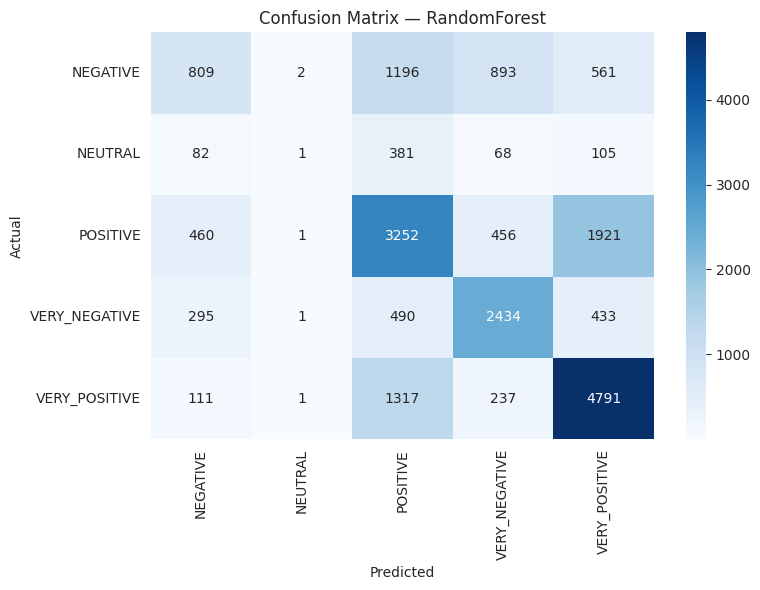

Macro AUC: 0.7895  95% CI [0.7844, 0.7945]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/RandomForest_roc_curve.png


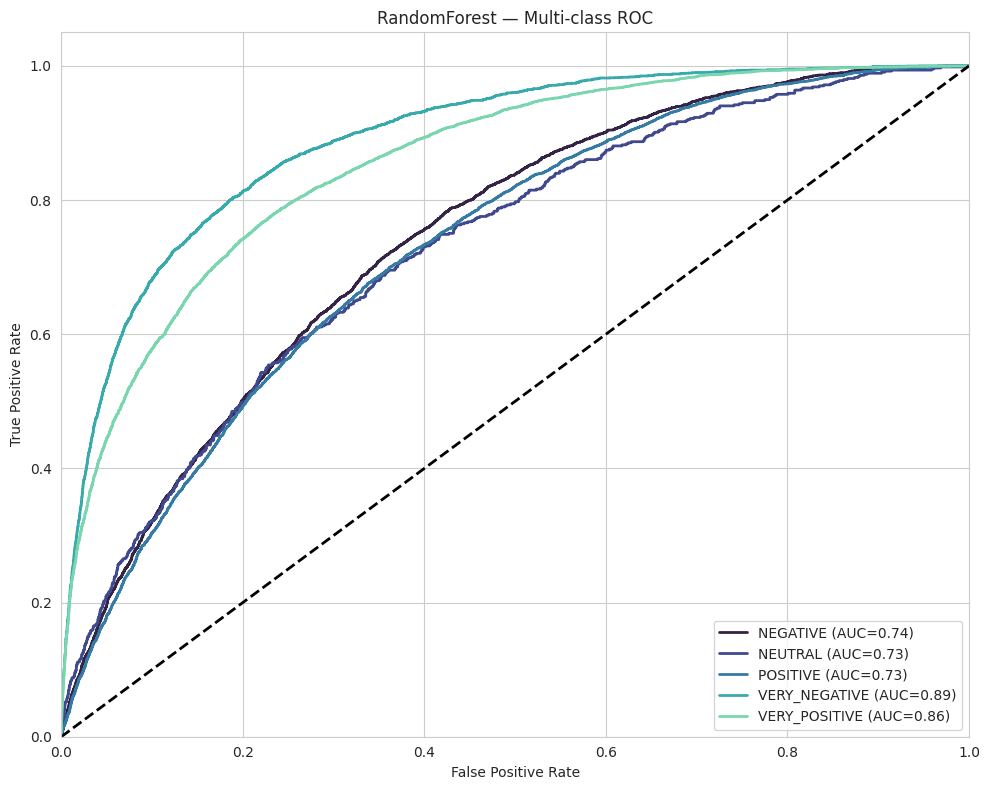

In [27]:
evaluate_ml(best_model_rf, X_test_tfidf, y_test_ml, "RandomForest")

### Step 3: Model Interpretation

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/randomforest_feature_importance.png


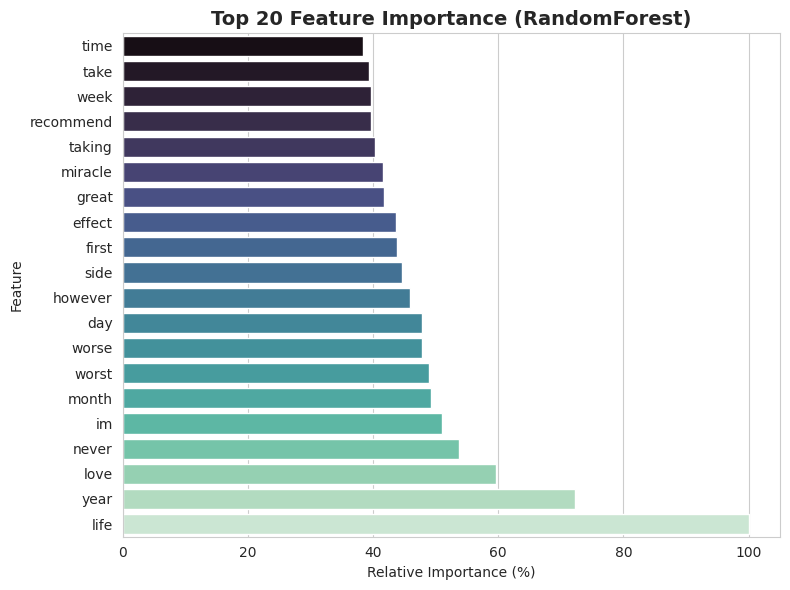

,Feature,Importance,Scaled
5345,life,0.010313,100.000000
9923,year,0.007446,72.202320
5498,love,0.006152,59.653247
6100,never,0.005549,53.806228
4728,im,0.005260,51.003115
5916,month,0.005075,49.207536
9862,worst,0.005050,48.973281
9857,worse,0.004936,47.861522
2750,day,0.004935,47.852589
4609,however,0.004734,45.908524


In [28]:
plot_feature_importance(best_model_rf.feature_importances_, feature_names_tfidf, "RandomForest")

## 3.2 LGBM

### Step 1: Hyperparameter Tuning

In [29]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning LightGBM...")
    start = time.time()

    lgbm_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "num_leaves": [31, 63],
        "max_depth": [None, 10],
        "class_weight": ["balanced", None],
    }

    best_f1_lgbm, best_model_lgbm, best_params_lgbm = 0, None, None

    for n_est, lr, nl, md, cw in tqdm(
        list(product(lgbm_grid["n_estimators"], lgbm_grid["learning_rate"],
                     lgbm_grid["num_leaves"], lgbm_grid["max_depth"],
                     lgbm_grid["class_weight"])),
        desc="LGBM grid"
    ):
        try:
            model = LGBMClassifier(
                objective="multiclass", n_estimators=n_est, learning_rate=lr,
                num_leaves=nl, max_depth=-1 if md is None else md,
                class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1,
                verbose=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lgbm:
                best_f1_lgbm = f1
                best_model_lgbm = model
                best_params_lgbm = {"n_estimators": n_est, "learning_rate": lr,
                                    "num_leaves": nl, "max_depth": md, "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LGBM tuning: {time.time()-start:.1f}s | Best F1={best_f1_lgbm:.4f}")
    print(f"Best params: {best_params_lgbm}")

    if best_model_lgbm is None:
        raise RuntimeError("No LightGBM candidate could be fitted - see the 'Skipped' messages above.")
    joblib.dump(best_model_lgbm, MODEL_PATHS["lgbm"]["model"])
    with open(MODEL_PATHS["lgbm"]["params"], "w") as f:
        json.dump(best_params_lgbm, f, indent=2)
else:
    print("Loading LGBM from disk...")
    best_model_lgbm = joblib.load(MODEL_PATHS["lgbm"]["model"])
    print(f"Loaded LGBM from {MODEL_PATHS['lgbm']['model']}")



Tuning LightGBM...


LGBM grid: 100%|██████████| 48/48 [1:22:55<00:00, 103.65s/it]

LGBM tuning: 4975.3s | Best F1=0.5880
Best params: {'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 63, 'max_depth': None, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: LightGBM
               precision    recall  f1-score   support

     NEGATIVE     0.4149    0.4097    0.4123      3461
      NEUTRAL     0.1418    0.1193    0.1296       637
     POSITIVE     0.5567    0.5220    0.5388      6090
VERY_NEGATIVE     0.6536    0.7169    0.6838      3653
VERY_POSITIVE     0.7094    0.7280    0.7186      6457

     accuracy                         0.5908     20298
    macro avg     0.4953    0.4992    0.4966     20298
 weighted avg     0.5855    0.5908    0.5877     20298

Weighted F1: 0.5877  95% CI [0.5806, 0.5941]
Macro F1:    0.4966  95% CI [0.4890, 0.5043]
Micro F1:    0.5908  95% CI [0.5843, 0.5973]  (= accuracy)
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/LightGBM_confusion_matrix.png


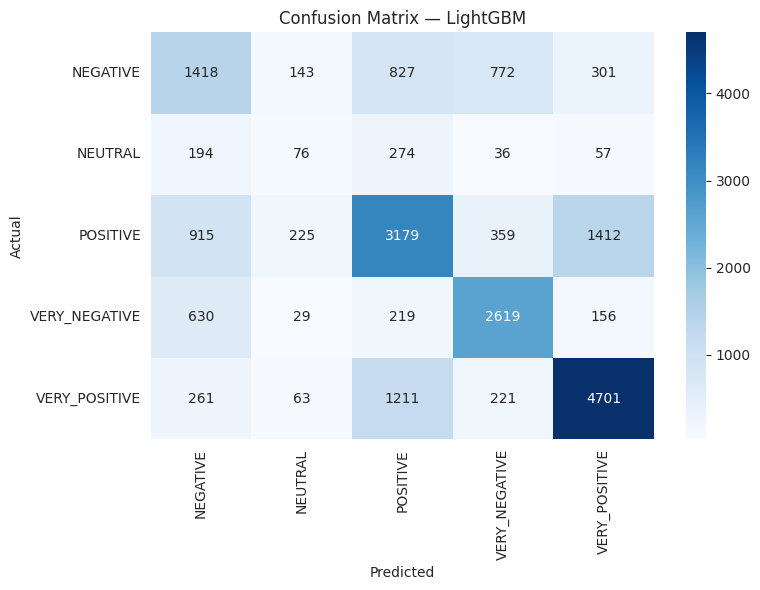

Macro AUC: 0.8259  95% CI [0.8210, 0.8308]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/LightGBM_roc_curve.png


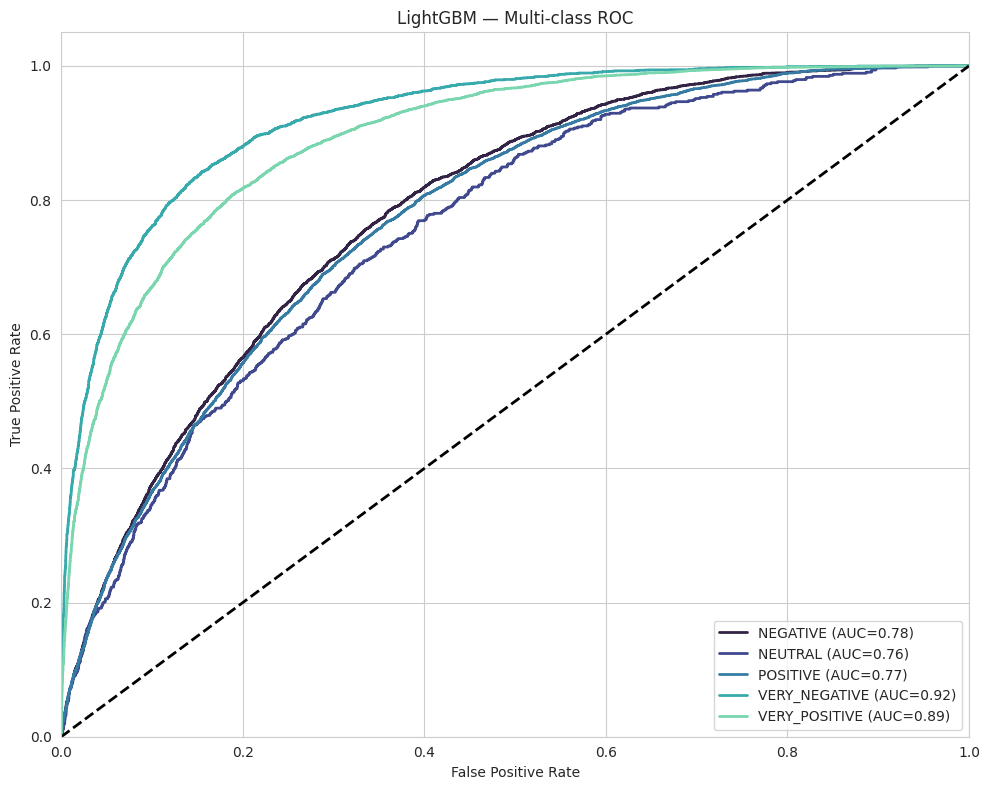

In [30]:
evaluate_ml(best_model_lgbm, X_test_tfidf, y_test_ml, "LightGBM")

### Step 3: Model Interpretation

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/lightgbm_feature_importance.png


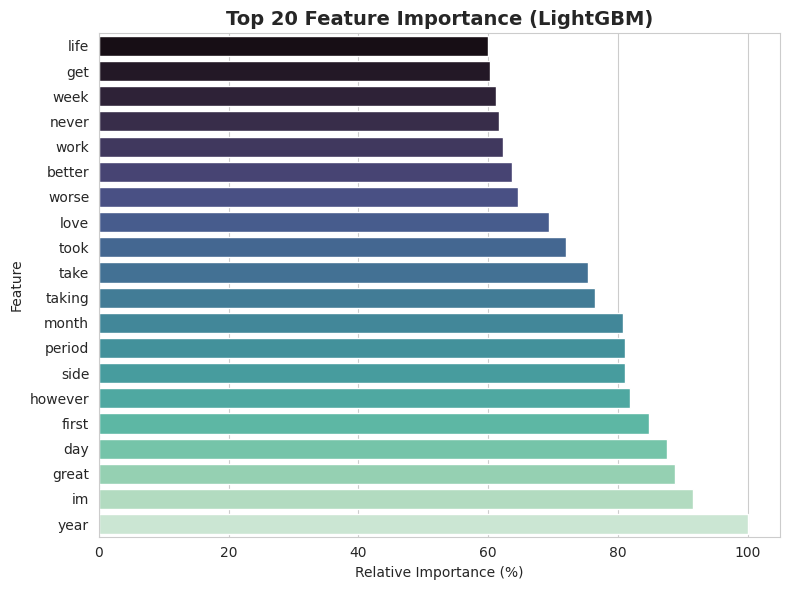

,Feature,Importance,Scaled
9923,year,297,100.000000
4728,im,272,91.582492
4280,great,264,88.888889
2750,day,260,87.542088
3862,first,252,84.848485
4609,however,243,81.818182
8061,side,241,81.144781
6652,period,241,81.144781
5916,month,240,80.808081
8777,taking,227,76.430976


In [33]:
plot_feature_importance(best_model_lgbm.feature_importances_, feature_names_tfidf, "LightGBM")

## 3.4 Save Predictions for Machine Learning Models

In [32]:
print("\nSaving ML predictions...")

y_true_str = df_test_ml[LABEL_COLUMN].astype(str).values
y_true_id  = label_encoder.transform(y_true_str)

lr_pred   = best_model_lr.predict(X_test_tfidf)
rf_pred   = best_model_rf.predict(X_test_tfidf)
lgbm_pred = best_model_lgbm.predict(X_test_tfidf)

lr_proba   = best_model_lr.predict_proba(X_test_tfidf)
rf_proba   = best_model_rf.predict_proba(X_test_tfidf)
lgbm_proba = best_model_lgbm.predict_proba(X_test_tfidf)

class_names_ml = best_model_lr.classes_
assert np.array_equal(class_names_ml, best_model_rf.classes_)
assert np.array_equal(class_names_ml, best_model_lgbm.classes_)

# Build prediction DataFrame
if "id" in df_test_ml.columns:
    df_pred_ml = df_test_ml[["id", TEXT_COLUMN]].copy()
else:
    df_pred_ml = df_test_ml[[TEXT_COLUMN]].copy()
    df_pred_ml.insert(0, "id", df_test_ml.index)

df_pred_ml.insert(1, ID_COLUMN, df_test_ml[ID_COLUMN].values)
df_pred_ml["true_label"]    = y_true_str
df_pred_ml["true_label_id"] = y_true_id
df_pred_ml["lr_pred"]       = lr_pred
df_pred_ml["rf_pred"]       = rf_pred
df_pred_ml["lgbm_pred"]     = lgbm_pred

for i, cls in enumerate(class_names_ml):
    df_pred_ml[f"lr_prob_{cls}"]   = lr_proba[:, i]
    df_pred_ml[f"rf_prob_{cls}"]   = rf_proba[:, i]
    df_pred_ml[f"lgbm_prob_{cls}"] = lgbm_proba[:, i]

ml_pred_path = OUTPUT_PATH / "ml_models_predictions.csv"
df_pred_ml.to_csv(ml_pred_path, index=False)
print(f"Saved ML predictions → {ml_pred_path}")

# Human-audit rows (never trained, validated or fitted on): same fitted vectorizers, same models.
df_audit_ml = df_ml[df_ml["split"] == "audit"].copy()
if not df_audit_ml.empty:
    X_audit_tfidf = hstack([
        tfidf_text.transform(safe_str(df_audit_ml["text_ml"])),
        tfidf_cond.transform(safe_str(df_audit_ml["condition_ml"])),
        tfidf_ing.transform(safe_str(df_audit_ml["ingredient_ml"])),
        csr_matrix(df_audit_ml["n_ingredients_capped"].values.reshape(-1, 1)),
    ], format="csr")

    df_pred_ml_audit = df_audit_ml[[ID_COLUMN, "narrative_group", "is_human_annotated", "audit_stratum"]].copy()
    df_pred_ml_audit["true_label"]    = df_audit_ml[LABEL_COLUMN].astype(str).values
    df_pred_ml_audit["true_label_id"] = label_encoder.transform(df_pred_ml_audit["true_label"])
    for _name, _model in [("lr", best_model_lr), ("rf", best_model_rf), ("lgbm", best_model_lgbm)]:
        df_pred_ml_audit[f"{_name}_pred"] = _model.predict(X_audit_tfidf)
        _proba = _model.predict_proba(X_audit_tfidf)
        for _i, _cls in enumerate(_model.classes_):
            df_pred_ml_audit[f"{_name}_prob_{_cls}"] = _proba[:, _i]

    _path = OUTPUT_PATH / "ml_models_predictions_audit.csv"
    df_pred_ml_audit.to_csv(_path, index=False)
    print(f"Audit rows: {len(df_pred_ml_audit)} ({int(df_pred_ml_audit['is_human_annotated'].sum())} human-annotated) → {_path}")


Saving ML predictions...
Saved ML predictions → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/ml_models_predictions.csv
Audit rows: 557 (500 human-annotated) → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/ml_models_predictions_audit.csv


# 4. DL Models


## 4.0 Pre-processing \& data preparation for DL Models

In [22]:
df_train_dl = df_clean[df_clean["split"] == "train"].copy()
df_val_dl   = df_clean[df_clean["split"] == "val"].copy()
df_test_dl  = df_clean[df_clean["split"] == "test"].copy()

train_labels_dl = df_train_dl[LABEL_COLUMN_ENCODED].tolist()
val_labels_dl   = df_val_dl[LABEL_COLUMN_ENCODED].tolist()
test_labels_dl  = df_test_dl[LABEL_COLUMN_ENCODED].tolist()

# ── GRU/CNN and Transformers use this condition's TEXT_COLUMN ──
train_texts_dl = df_train_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
val_texts_dl   = df_val_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
test_texts_dl  = df_test_dl[TEXT_COLUMN].fillna("").astype(str).tolist()

print(f"DL splits: train={len(train_texts_dl)}, val={len(val_texts_dl)}, test={len(test_texts_dl)}")

# ── Build shared vocabulary (GRU + CNN — from raw text) ──
# PAD=0, UNK=1, words start at 2
vocab_counter = Counter()
for text in train_texts_dl:
    vocab_counter.update(text.split())
most_common = [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]  # -2 for PAD and UNK
word_to_index = {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK
UNK_IDX = 1

print(f"Vocabulary: {len(word_to_index)} words + PAD(0) + UNK(1)")


def text_to_sequence(text, w2i, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    return [w2i.get(w, UNK_IDX) for w in tokens][:max_len]


# ── Convert & pad sequences (fixed length = MAX_TOKEN_LENGTH) ──
def build_padded_sequences(texts, w2i, max_len=MAX_TOKEN_LENGTH):
    seqs = []
    for t in texts:
        seq = text_to_sequence(t, w2i, max_len)
        # Pad to exactly max_len. Keep real tokens last for the GRU final-state readout.
        # This restores the previously agreed shared GRU/CNN input preparation.
        padded = [0] * (max_len - len(seq)) + seq      # left-pad: real tokens come last
        seqs.append(padded)
    return torch.tensor(seqs, dtype=torch.long)


train_seqs = build_padded_sequences(train_texts_dl, word_to_index)
val_seqs   = build_padded_sequences(val_texts_dl, word_to_index)
test_seqs  = build_padded_sequences(test_texts_dl, word_to_index)

train_labels_t = torch.tensor(train_labels_dl, dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_dl, dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_dl, dtype=torch.long)

print(f"Sequence shapes: train={train_seqs.shape}, val={val_seqs.shape}, test={test_seqs.shape}")

with open(OUTPUT_PATH / "seq_vocabulary.json", "w") as _f:
    json.dump({"pad": 0, "unk": UNK_IDX, "max_len": MAX_TOKEN_LENGTH, "word_to_index": word_to_index}, _f)


DL splits: train=60950, val=20256, test=20298
Vocabulary: 9998 words + PAD(0) + UNK(1)
Sequence shapes: train=torch.Size([60950, 200]), val=torch.Size([20256, 200]), test=torch.Size([20298, 200])


In [23]:
# ── Dataset class (GRU + CNN) ────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids": self.sequences[idx], "label": self.labels[idx]}


# ── DataLoaders (shared, with pin_memory) ────────────────
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                  pin_memory=True, persistent_workers=True)

train_loader_seq = DataLoader(SeqDataset(train_seqs, train_labels_t), shuffle=True,
                              generator=torch.Generator().manual_seed(SEED), **_loader_kw)
val_loader_seq   = DataLoader(SeqDataset(val_seqs, val_labels_t), shuffle=False, generator=torch.Generator().manual_seed(SEED + 100_000), **_loader_kw)
test_loader_seq  = DataLoader(SeqDataset(test_seqs, test_labels_t), shuffle=False, generator=torch.Generator().manual_seed(SEED + 200_000), **_loader_kw)

# ── Class weights for DL training ────────────────────────
_cw = compute_class_weight("balanced", classes=np.unique(train_labels_dl), y=train_labels_dl)
class_weights_dl = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

## 4.1 Neural Network (GRU \& CNN)

### 4.1.1 Generic train + evaluation

In [24]:
def train_seq_model(model, train_loader, val_loader, lr=1e-3,
                    max_epochs=20, patience=5):
    """Train a sequence model (GRU or CNN) with early stopping."""
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                logits = model(ids)
                loss = criterion(logits, labels)
            checked_optimizer_step(loss, model, optimizer, scaler, SEQ_MAX_GRAD_NORM)
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE, non_blocking=True)
                labels = batch["label"]
                with autocast("cuda", enabled=USE_FP16):
                    logits = model(ids)
                require_finite_tensor(logits, "validation logits")
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(labels.numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        val_acc = accuracy_score(val_true, val_preds)
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | "
              f"Val F1={val_f1:.4f} | Val Acc={val_acc:.4f}")

        if val_f1 > best_f1:
            require_finite_model(model)
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model

### 4.1.2 GRU

#### Step 1: Define GRU Model

In [25]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)
        return self.fc(self.dropout(hidden[-1]))

#### Step 2: Hyperparameter Tuning

In [26]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning GRU...")
    start = time.time()

    MAX_EPOCHS_GRU = 20
    PATIENCE_GRU = 5

    gru_param_space = {
        "embedding_dim": (150, 300),
        "hidden_dim": (128, 384),
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_gru, best_params_gru, best_gru = -1.0, None, None

    # All configurations are drawn first (same values as before: same seed, same order of draws),
    # so a trial does not depend on how much randomness the earlier trials consumed.
    hp_trials = []
    for _ in range(N_ITERATIONS):
        hp = {
            "embedding_dim": int(np.random.uniform(*gru_param_space["embedding_dim"])),
            "hidden_dim": int(np.random.uniform(*gru_param_space["hidden_dim"])),
            "lr": float(10 ** np.random.uniform(*gru_param_space["lr"])),
        }
        hp_trials.append(hp)
    trial_log = []

    for i in tqdm(range(N_ITERATIONS), desc="GRU Random Search"):
        hp = dict(hp_trials[i])
        trial_seed = SEED + i                       # each trial reproducible on its own
        set_seed(trial_seed)
        # A fresh loader gives standalone and full-search trials the same shuffle state.
        train_loader_seq = DataLoader(
            SeqDataset(train_seqs, train_labels_t), shuffle=True,
            generator=torch.Generator().manual_seed(trial_seed), **_loader_kw,
        )

        model = GRUSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            hidden_dim=hp["hidden_dim"], output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_GRU, patience=PATIENCE_GRU,
        )

        trial_log.append({"trial": i + 1, "seed": trial_seed, "val_f1": float(f1_val),
                          **{k: v for k, v in hp.items() if isinstance(v, (int, float, str))}})
        if f1_val > best_f1_gru:
            best_f1_gru = f1_val
            best_params_gru = {**hp, "trial_seed": trial_seed}
            best_gru = model

    pd.DataFrame(trial_log).to_csv(OUTPUT_PATH / "gru_trial_log.csv", index=False)
    print(f"GRU tuning: {time.time()-start:.1f}s | Best F1={best_f1_gru:.4f}")
    print(f"Best params: {best_params_gru}")

    torch.save(best_gru.state_dict(), MODEL_PATHS["gru"]["model"])
    with open(MODEL_PATHS["gru"]["params"], "w") as f:
        json.dump(best_params_gru, f, indent=2)
else:
    print("Loading GRU from disk...")
    with open(MODEL_PATHS["gru"]["params"]) as f:
        best_params_gru = json.load(f)
    best_gru = GRUSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_gru["embedding_dim"]),
        hidden_dim=int(best_params_gru["hidden_dim"]), output_dim=NUM_CLASSES,
    )
    best_gru.load_state_dict(torch.load(MODEL_PATHS["gru"]["model"], map_location=DEVICE))
    print(f"Loaded GRU from {MODEL_PATHS['gru']['model']}")



Tuning GRU...


GRU Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.3974 | Val F1=0.4760 | Val Acc=0.4459
  Epoch 2/20 | Loss=1.0738 | Val F1=0.5813 | Val Acc=0.5795
  Epoch 3/20 | Loss=0.8861 | Val F1=0.6032 | Val Acc=0.5666
  Epoch 4/20 | Loss=0.7275 | Val F1=0.6244 | Val Acc=0.6074
  Epoch 5/20 | Loss=0.5744 | Val F1=0.6504 | Val Acc=0.6424
  Epoch 6/20 | Loss=0.4375 | Val F1=0.6515 | Val Acc=0.6458
  Epoch 7/20 | Loss=0.3310 | Val F1=0.6487 | Val Acc=0.6492
  Epoch 8/20 | Loss=0.2496 | Val F1=0.6523 | Val Acc=0.6508
  Epoch 9/20 | Loss=0.1843 | Val F1=0.6556 | Val Acc=0.6567
  Epoch 10/20 | Loss=0.1445 | Val F1=0.6382 | Val Acc=0.6408
  Epoch 11/20 | Loss=0.1090 | Val F1=0.6502 | Val Acc=0.6470
  Epoch 12/20 | Loss=0.0981 | Val F1=0.6409 | Val Acc=0.6372
  Epoch 13/20 | Loss=0.0820 | Val F1=0.6466 | Val Acc=0.6426


GRU Random Search:  10%|█         | 1/10 [00:53<07:57, 53.06s/it]

  Epoch 14/20 | Loss=0.0749 | Val F1=0.6376 | Val Acc=0.6310
  Early stopping at epoch 14.
  Epoch 1/20 | Loss=1.5382 | Val F1=0.4131 | Val Acc=0.3796
  Epoch 2/20 | Loss=1.2845 | Val F1=0.4681 | Val Acc=0.4688
  Epoch 3/20 | Loss=1.1511 | Val F1=0.5134 | Val Acc=0.5269
  Epoch 4/20 | Loss=1.0750 | Val F1=0.5268 | Val Acc=0.4903
  Epoch 5/20 | Loss=1.0106 | Val F1=0.5653 | Val Acc=0.5657
  Epoch 6/20 | Loss=0.9521 | Val F1=0.5778 | Val Acc=0.5777
  Epoch 7/20 | Loss=0.8977 | Val F1=0.5806 | Val Acc=0.5658
  Epoch 8/20 | Loss=0.8528 | Val F1=0.5860 | Val Acc=0.5726
  Epoch 9/20 | Loss=0.8033 | Val F1=0.5905 | Val Acc=0.5736
  Epoch 10/20 | Loss=0.7552 | Val F1=0.5676 | Val Acc=0.5594
  Epoch 11/20 | Loss=0.7123 | Val F1=0.6028 | Val Acc=0.5840
  Epoch 12/20 | Loss=0.6705 | Val F1=0.6022 | Val Acc=0.5975
  Epoch 13/20 | Loss=0.6360 | Val F1=0.6142 | Val Acc=0.6064
  Epoch 14/20 | Loss=0.5958 | Val F1=0.6131 | Val Acc=0.6153
  Epoch 15/20 | Loss=0.5642 | Val F1=0.6057 | Val Acc=0.6016
  E

...

  Epoch 20/20 | Loss=0.4489 | Val F1=0.6240 | Val Acc=0.6223
  Epoch 1/20 | Loss=1.4762 | Val F1=0.4275 | Val Acc=0.4113
  Epoch 2/20 | Loss=1.2198 | Val F1=0.5172 | Val Acc=0.5230
  Epoch 3/20 | Loss=1.0894 | Val F1=0.5084 | Val Acc=0.4957
  Epoch 4/20 | Loss=1.0022 | Val F1=0.5659 | Val Acc=0.5398
  Epoch 5/20 | Loss=0.9228 | Val F1=0.5547 | Val Acc=0.5251
  Epoch 6/20 | Loss=0.8464 | Val F1=0.5871 | Val Acc=0.5847
  Epoch 7/20 | Loss=0.7792 | Val F1=0.6111 | Val Acc=0.6041
  Epoch 8/20 | Loss=0.7160 | Val F1=0.6070 | Val Acc=0.5968
  Epoch 9/20 | Loss=0.6558 | Val F1=0.6181 | Val Acc=0.6164
  Epoch 10/20 | Loss=0.5928 | Val F1=0.6299 | Val Acc=0.6191
  Epoch 11/20 | Loss=0.5485 | Val F1=0.6388 | Val Acc=0.6370
  Epoch 12/20 | Loss=0.4948 | Val F1=0.6361 | Val Acc=0.6289
  Epoch 13/20 | Loss=0.4491 | Val F1=0.6332 | Val Acc=0.6293
  Epoch 14/20 | Loss=0.4142 | Val F1=0.6365 | Val Acc=0.6308
  Epoch 15/20 | Loss=0.3753 | Val F1=0.6460 | Val Acc=0.6415
  Epoch 16/20 | Loss=0.3436 | Val

GRU Random Search:  90%|█████████ | 9/10 [08:21<01:01, 61.98s/it]

  Epoch 20/20 | Loss=0.2213 | Val F1=0.6349 | Val Acc=0.6436
  Early stopping at epoch 20.
  Epoch 1/20 | Loss=1.5929 | Val F1=0.3099 | Val Acc=0.2954
  Epoch 2/20 | Loss=1.5077 | Val F1=0.3991 | Val Acc=0.4089
  Epoch 3/20 | Loss=1.3159 | Val F1=0.4608 | Val Acc=0.4478
  Epoch 4/20 | Loss=1.1987 | Val F1=0.5043 | Val Acc=0.5004
  Epoch 5/20 | Loss=1.1233 | Val F1=0.5228 | Val Acc=0.5140
  Epoch 6/20 | Loss=1.0723 | Val F1=0.5271 | Val Acc=0.5288
  Epoch 7/20 | Loss=1.0280 | Val F1=0.5460 | Val Acc=0.5420
  Epoch 8/20 | Loss=0.9907 | Val F1=0.5529 | Val Acc=0.5489
  Epoch 9/20 | Loss=0.9556 | Val F1=0.5544 | Val Acc=0.5428
  Epoch 10/20 | Loss=0.9252 | Val F1=0.5548 | Val Acc=0.5457
  Epoch 11/20 | Loss=0.8967 | Val F1=0.5771 | Val Acc=0.5745
  Epoch 12/20 | Loss=0.8666 | Val F1=0.5871 | Val Acc=0.5790
  Epoch 13/20 | Loss=0.8379 | Val F1=0.5821 | Val Acc=0.5789
  Epoch 14/20 | Loss=0.8135 | Val F1=0.5860 | Val Acc=0.5708
  Epoch 15/20 | Loss=0.7873 | Val F1=0.5724 | Val Acc=0.5666
  E

GRU Random Search: 100%|██████████| 10/10 [09:21<00:00, 56.11s/it]

  Epoch 20/20 | Loss=0.6708 | Val F1=0.6047 | Val Acc=0.5984
GRU tuning: 561.1s | Best F1=0.6564
Best params: {'embedding_dim': 193, 'hidden_dim': 284, 'lr': 0.0008185164112182907, 'trial_seed': 2030}


#### Step 3: Model Evaluation

Eval GRU: 100%|██████████| 159/159 [00:00<00:00, 402.80it/s]



Evaluation: GRU
               precision    recall  f1-score   support

VERY_NEGATIVE     0.7550    0.7391    0.7470      3653
     NEGATIVE     0.4939    0.5493    0.5201      3461
      NEUTRAL     0.1532    0.1790    0.1651       637
     POSITIVE     0.6241    0.5847    0.6038      6090
VERY_POSITIVE     0.7725    0.7685    0.7705      6457

     accuracy                         0.6522     20298
    macro avg     0.5598    0.5641    0.5613     20298
 weighted avg     0.6579    0.6522    0.6545     20298

Weighted F1: 0.6545  95% CI [0.6484, 0.6612]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/GRU_confusion_matrix.png


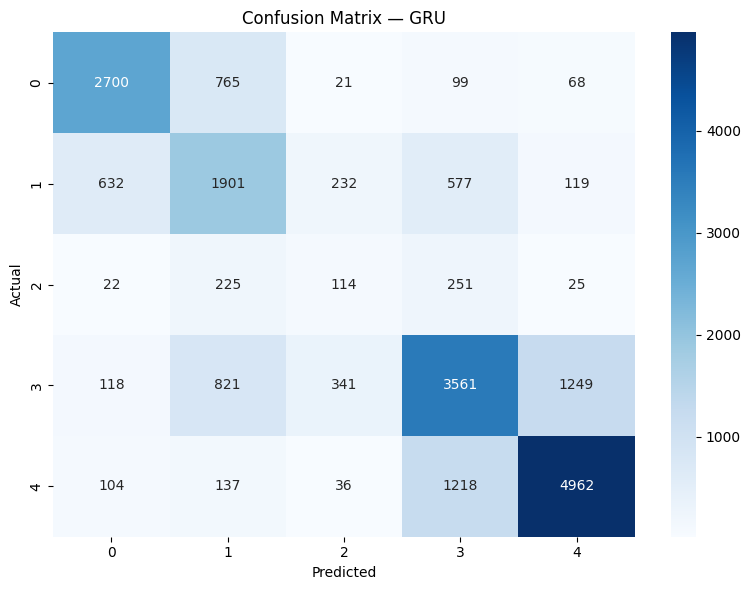

Macro AUC: 0.8752  95% CI [0.8713, 0.8790]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/GRU_roc_curve.png


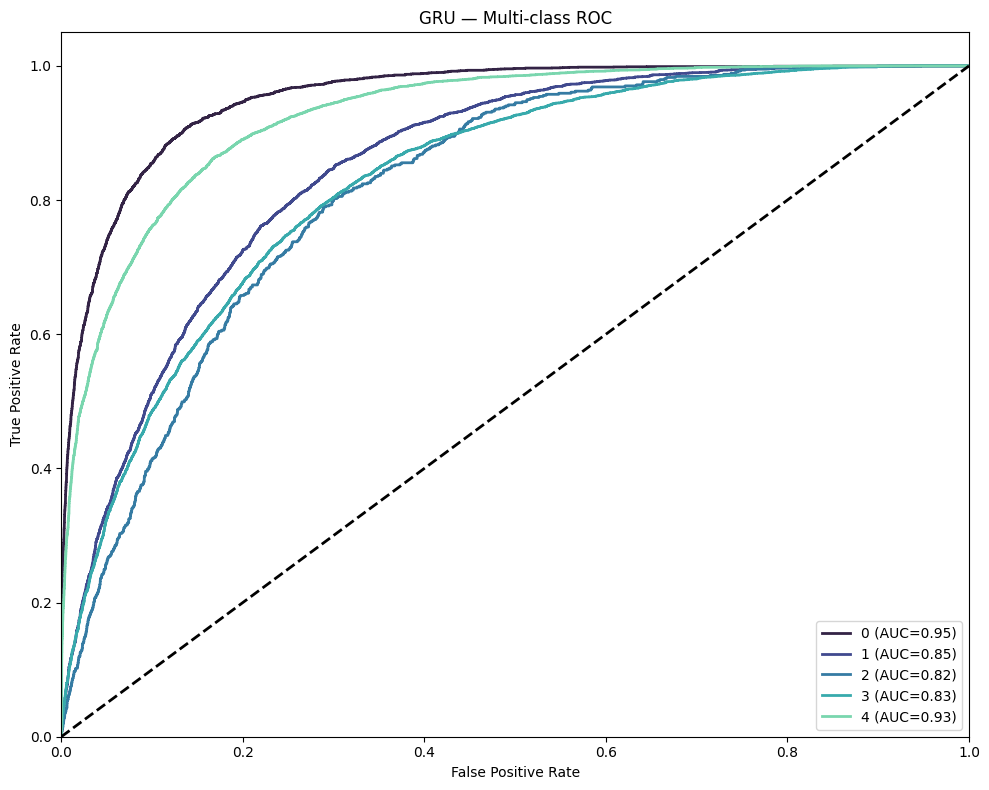

In [27]:
gru_preds, gru_probs, y_true_gru = evaluate_pytorch(
    best_gru, test_loader_seq, label_encoder, "GRU", use_attention_mask=False
)

### 4.1.3 CNN

### 4.2.2 CNN Modeling

#### Step 1: Define CNN Model

In [28]:
class CNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes,
                 output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.fc = nn.Linear(num_filters * len(filter_sizes), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.embedding(input_ids).permute(0, 2, 1)  # [B, E, L]
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat))

#### Step 2: Hyperparameter Tuning

In [29]:
RETRAIN = True

FILTER_SIZES = [3, 4, 5]

if RETRAIN:
    set_seed()
    print("\nTuning CNN...")
    start = time.time()

    MAX_EPOCHS_CNN = 20
    PATIENCE_CNN = 5

    cnn_param_space = {
        "embedding_dim": (150, 300),     # uniform
        "num_filters":  (80, 200),       # filters per kernel size
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_cnn, best_params_cnn, best_cnn = -1.0, None, None

    # All configurations are drawn first (same values as before: same seed, same order of draws),
    # so a trial does not depend on how much randomness the earlier trials consumed.
    hp_trials = []
    for _ in range(N_ITERATIONS):
        hp = {
            "embedding_dim": int(np.random.uniform(*cnn_param_space["embedding_dim"])),
            "num_filters": int(np.random.uniform(*cnn_param_space["num_filters"])),
            "lr": float(10 ** np.random.uniform(*cnn_param_space["lr"])),
        }
        hp_trials.append(hp)
    trial_log = []

    for i in tqdm(range(N_ITERATIONS), desc="CNN Random Search"):
        hp = dict(hp_trials[i])
        trial_seed = SEED + i                       # each trial reproducible on its own
        set_seed(trial_seed)
        # A fresh loader gives standalone and full-search trials the same shuffle state.
        train_loader_seq = DataLoader(
            SeqDataset(train_seqs, train_labels_t), shuffle=True,
            generator=torch.Generator().manual_seed(trial_seed), **_loader_kw,
        )

        model = CNNSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            num_filters=hp["num_filters"], filter_sizes=FILTER_SIZES,
            output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_CNN, patience=PATIENCE_CNN,
        )

        trial_log.append({"trial": i + 1, "seed": trial_seed, "val_f1": float(f1_val),
                          **{k: v for k, v in hp.items() if isinstance(v, (int, float, str))}})
        if f1_val > best_f1_cnn:
            best_f1_cnn = f1_val
            best_params_cnn = {**hp, "trial_seed": trial_seed}
            best_cnn = model

    pd.DataFrame(trial_log).to_csv(OUTPUT_PATH / "cnn_trial_log.csv", index=False)
    print(f"CNN tuning: {time.time()-start:.1f}s | Best F1={best_f1_cnn:.4f}")
    print(f"Best params: {best_params_cnn}")

    torch.save(best_cnn.state_dict(), MODEL_PATHS["cnn"]["model"])
    with open(MODEL_PATHS["cnn"]["params"], "w") as f:
        json.dump(best_params_cnn, f, indent=2)
else:
    print("Loading CNN from disk...")
    with open(MODEL_PATHS["cnn"]["params"]) as f:
        best_params_cnn = json.load(f)
    best_cnn = CNNSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_cnn["embedding_dim"]),
        num_filters=int(best_params_cnn["num_filters"]), filter_sizes=FILTER_SIZES,
        output_dim=NUM_CLASSES,
    )
    best_cnn.load_state_dict(torch.load(MODEL_PATHS["cnn"]["model"], map_location=DEVICE))
    print(f"Loaded CNN from {MODEL_PATHS['cnn']['model']}")


Tuning CNN...


CNN Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.4667 | Val F1=0.4629 | Val Acc=0.4556
  Epoch 2/20 | Loss=1.2015 | Val F1=0.4886 | Val Acc=0.5147
  Epoch 3/20 | Loss=1.0607 | Val F1=0.5660 | Val Acc=0.5583
  Epoch 4/20 | Loss=0.9434 | Val F1=0.5796 | Val Acc=0.5744
  Epoch 5/20 | Loss=0.8095 | Val F1=0.6310 | Val Acc=0.6349
  Epoch 6/20 | Loss=0.6828 | Val F1=0.6220 | Val Acc=0.6253
  Epoch 7/20 | Loss=0.5635 | Val F1=0.6247 | Val Acc=0.6158
  Epoch 8/20 | Loss=0.4683 | Val F1=0.6301 | Val Acc=0.6305
  Epoch 9/20 | Loss=0.4031 | Val F1=0.6256 | Val Acc=0.6239


CNN Random Search:  10%|█         | 1/10 [00:12<01:56, 12.90s/it]

  Epoch 10/20 | Loss=0.3446 | Val F1=0.6165 | Val Acc=0.6147
  Early stopping at epoch 10.
  Epoch 1/20 | Loss=1.5728 | Val F1=0.4848 | Val Acc=0.4701
  Epoch 2/20 | Loss=1.3378 | Val F1=0.5194 | Val Acc=0.5064
  Epoch 3/20 | Loss=1.2158 | Val F1=0.5636 | Val Acc=0.5626
  Epoch 4/20 | Loss=1.1371 | Val F1=0.5695 | Val Acc=0.5580
  Epoch 5/20 | Loss=1.0689 | Val F1=0.5706 | Val Acc=0.5642
  Epoch 6/20 | Loss=1.0140 | Val F1=0.5950 | Val Acc=0.5877
  Epoch 7/20 | Loss=0.9590 | Val F1=0.5995 | Val Acc=0.5914
  Epoch 8/20 | Loss=0.9122 | Val F1=0.6044 | Val Acc=0.6059
  Epoch 9/20 | Loss=0.8614 | Val F1=0.6023 | Val Acc=0.5951
  Epoch 10/20 | Loss=0.8273 | Val F1=0.6152 | Val Acc=0.6195
  Epoch 11/20 | Loss=0.7856 | Val F1=0.6166 | Val Acc=0.6154
  Epoch 12/20 | Loss=0.7473 | Val F1=0.6189 | Val Acc=0.6150
  Epoch 13/20 | Loss=0.7058 | Val F1=0.6200 | Val Acc=0.6169
  Epoch 14/20 | Loss=0.6697 | Val F1=0.6198 | Val Acc=0.6166
  Epoch 15/20 | Loss=0.6385 | Val F1=0.6254 | Val Acc=0.6275
  E

...

  Epoch 19/20 | Loss=0.5143 | Val F1=0.6300 | Val Acc=0.6310
  Early stopping at epoch 19.
  Epoch 1/20 | Loss=1.5317 | Val F1=0.4737 | Val Acc=0.4377
  Epoch 2/20 | Loss=1.2507 | Val F1=0.5779 | Val Acc=0.5802
  Epoch 3/20 | Loss=1.1147 | Val F1=0.5644 | Val Acc=0.5504
  Epoch 4/20 | Loss=1.0111 | Val F1=0.5899 | Val Acc=0.5773
  Epoch 5/20 | Loss=0.9273 | Val F1=0.5912 | Val Acc=0.5907
  Epoch 6/20 | Loss=0.8569 | Val F1=0.6162 | Val Acc=0.6116
  Epoch 7/20 | Loss=0.7938 | Val F1=0.6289 | Val Acc=0.6266
  Epoch 8/20 | Loss=0.7317 | Val F1=0.6304 | Val Acc=0.6267
  Epoch 9/20 | Loss=0.6764 | Val F1=0.6179 | Val Acc=0.6181
  Epoch 10/20 | Loss=0.6280 | Val F1=0.6316 | Val Acc=0.6345
  Epoch 11/20 | Loss=0.5792 | Val F1=0.6316 | Val Acc=0.6347
  Epoch 12/20 | Loss=0.5365 | Val F1=0.6284 | Val Acc=0.6286
  Epoch 13/20 | Loss=0.4958 | Val F1=0.6363 | Val Acc=0.6392
  Epoch 14/20 | Loss=0.4525 | Val F1=0.6361 | Val Acc=0.6403
  Epoch 15/20 | Loss=0.4133 | Val F1=0.6337 | Val Acc=0.6406
  E

CNN Random Search:  90%|█████████ | 9/10 [03:07<00:23, 23.20s/it]

  Epoch 18/20 | Loss=0.3096 | Val F1=0.6309 | Val Acc=0.6381
  Early stopping at epoch 18.
  Epoch 1/20 | Loss=1.6330 | Val F1=0.4001 | Val Acc=0.3755
  Epoch 2/20 | Loss=1.4528 | Val F1=0.4751 | Val Acc=0.4764
  Epoch 3/20 | Loss=1.3482 | Val F1=0.5293 | Val Acc=0.5256
  Epoch 4/20 | Loss=1.2669 | Val F1=0.5190 | Val Acc=0.5088
  Epoch 5/20 | Loss=1.2049 | Val F1=0.5344 | Val Acc=0.5318
  Epoch 6/20 | Loss=1.1613 | Val F1=0.5561 | Val Acc=0.5469
  Epoch 7/20 | Loss=1.1128 | Val F1=0.5519 | Val Acc=0.5568
  Epoch 8/20 | Loss=1.0815 | Val F1=0.5812 | Val Acc=0.5777
  Epoch 9/20 | Loss=1.0451 | Val F1=0.5841 | Val Acc=0.5798
  Epoch 10/20 | Loss=1.0179 | Val F1=0.5852 | Val Acc=0.5788
  Epoch 11/20 | Loss=0.9840 | Val F1=0.5952 | Val Acc=0.5955
  Epoch 12/20 | Loss=0.9527 | Val F1=0.5939 | Val Acc=0.5925
  Epoch 13/20 | Loss=0.9311 | Val F1=0.5842 | Val Acc=0.5719
  Epoch 14/20 | Loss=0.9056 | Val F1=0.5987 | Val Acc=0.5939
  Epoch 15/20 | Loss=0.8771 | Val F1=0.6051 | Val Acc=0.6000
  E

CNN Random Search: 100%|██████████| 10/10 [03:33<00:00, 21.32s/it]

  Epoch 20/20 | Loss=0.7568 | Val F1=0.6192 | Val Acc=0.6156
CNN tuning: 213.2s | Best F1=0.6363
Best params: {'embedding_dim': 287, 'num_filters': 193, 'lr': 0.00018953847119167257, 'trial_seed': 2033}


#### Step 3: Model Evaluation

Eval CNN: 100%|██████████| 159/159 [00:00<00:00, 1019.58it/s]


Evaluation: CNN
               precision    recall  f1-score   support

VERY_NEGATIVE     0.7243    0.7221    0.7232      3653
     NEGATIVE     0.4843    0.5539    0.5168      3461
      NEUTRAL     0.2286    0.0754    0.1133       637
     POSITIVE     0.6051    0.6171    0.6110      6090
VERY_POSITIVE     0.7660    0.7446    0.7551      6457

     accuracy                         0.6488     20298
    macro avg     0.5617    0.5426    0.5439     20298
 weighted avg     0.6453    0.6488    0.6454     20298



Weighted F1: 0.6454  95% CI [0.6391, 0.6524]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/CNN_confusion_matrix.png


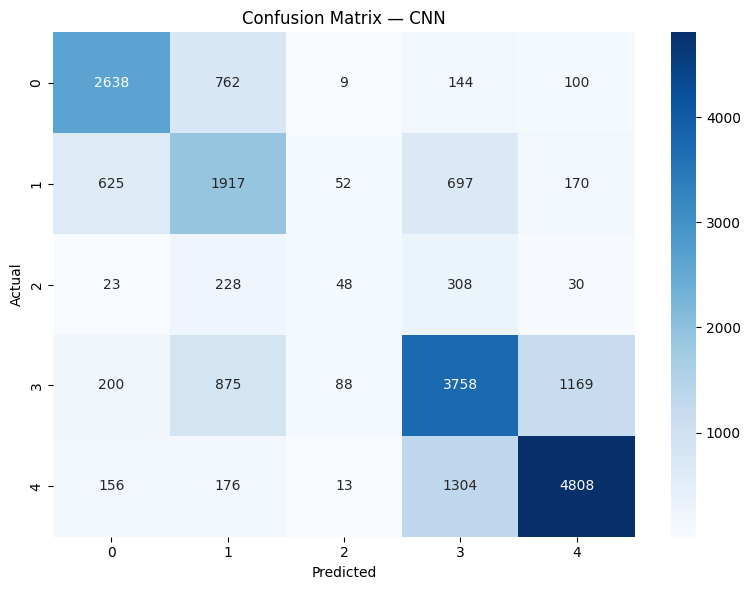

Macro AUC: 0.8706  95% CI [0.8669, 0.8743]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/CNN_roc_curve.png


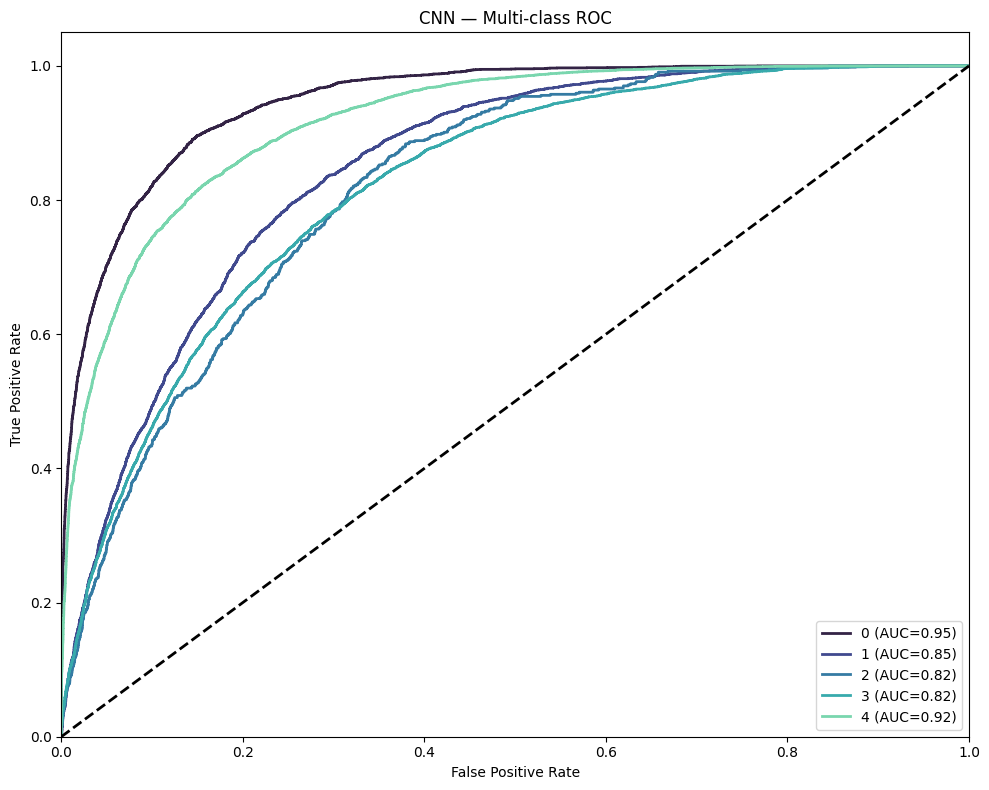

In [30]:
cnn_preds, cnn_probs, y_true_cnn = evaluate_pytorch(
    best_cnn, test_loader_seq, label_encoder, "CNN", use_attention_mask=False
)

## 4.2 Transformer

### 4.2.1 Generic transformer train function

In [31]:
def train_transformer(model, train_loader, val_loader,
                      lr=2e-5, max_epochs=6, patience=2):
    """Fine-tune a HuggingFace transformer with FP16, grad clip, OneCycleLR."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0
    selected_epoch = None

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, labels)

            checked_optimizer_step(loss, model, optimizer, scaler, MAX_GRAD_NORM, scheduler)
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                with autocast("cuda", enabled=USE_FP16):
                    out = model(input_ids=ids, attention_mask=mask)
                logits = out.logits if hasattr(out, "logits") else out
                require_finite_tensor(logits, "validation logits")
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            require_finite_model(model)
            selected_epoch = epoch
            best_f1 = val_f1
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    if best_state:
        raw.load_state_dict(best_state)
    if best_state is None:
        raise RuntimeError("No valid transformer checkpoint selected.")
    raw.training_record = {"selected_epoch": selected_epoch, "validation_weighted_f1": float(best_f1)}
    return best_f1, raw

### 4.2.2 ALBERT

#### Step 1: Data Preparation

In [32]:
print("\nPre-tokenizing for ALBERT...")
albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")


def batch_tokenize(texts, tokenizer, max_len, batch_size=512):
    all_ids, all_masks = [], []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size], max_length=max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        all_ids.append(enc["input_ids"])
        all_masks.append(enc["attention_mask"])
    return torch.cat(all_ids), torch.cat(all_masks)


# Use same text lists as DL
train_ids_albert, train_masks_albert = batch_tokenize(train_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_albert, val_masks_albert     = batch_tokenize(val_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_albert, test_masks_albert   = batch_tokenize(test_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
print(f"ALBERT tokens: train={train_ids_albert.shape}")


# ── Cached dataset for transformers ──────────────────────
class TransformerDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }


_tf_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader_albert = DataLoader(
    TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
    shuffle=True, generator=torch.Generator().manual_seed(SEED), **_tf_loader_kw)
val_loader_albert = DataLoader(
    TransformerDataset(val_ids_albert, val_masks_albert, val_labels_dl),
    shuffle=False, generator=torch.Generator().manual_seed(SEED + 100_000), **_tf_loader_kw)
test_loader_albert = DataLoader(
    TransformerDataset(test_ids_albert, test_masks_albert, test_labels_dl),
    shuffle=False, generator=torch.Generator().manual_seed(SEED + 100_000), **_tf_loader_kw)


Pre-tokenizing for ALBERT...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ALBERT tokens: train=torch.Size([60950, 200])


#### Step 2: Hyperparameter Tuning

In [33]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning ALBERT...")
    start = time.time()

    albert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    hp_trials = []
    for _ in range(N_ITERATIONS):
        hp = {
            "lr": float(10 ** np.random.uniform(*albert_param_space["lr"])),
            "epochs": int(np.random.randint(*albert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*albert_param_space["dropout"])),
        }
        hp_trials.append(hp)
    trial_log = []

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Random Search"):
        hp = dict(hp_trials[i])
        trial_seed = SEED + i
        set_seed(trial_seed)
        train_loader_albert = DataLoader(
            TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
            shuffle=True, generator=torch.Generator().manual_seed(trial_seed), **_tf_loader_kw)

        model = AlbertForSequenceClassification.from_pretrained(
            "albert-base-v2", num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        trial_log.append({"trial": i + 1, "seed": trial_seed, "val_f1": float(f1_val),
                          **hp, **model.training_record})
        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = {**hp, "trial_seed": trial_seed}
            best_albert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    torch.save(best_albert.state_dict(), MODEL_PATHS["albert"]["model"])
    pd.DataFrame(trial_log).to_csv(OUTPUT_PATH / "albert_trial_log.csv", index=False)
    save_transformer_record(best_albert, albert_tokenizer, best_params_albert, "albert")
else:
    print("Loading ALBERT from disk...")
    config_path = OUTPUT_PATH / "albert_config"
    saved_config = AutoConfig.from_pretrained(config_path if config_path.exists() else "albert-base-v2", num_labels=NUM_CLASSES)
    best_albert = AlbertForSequenceClassification.from_pretrained("albert-base-v2", config=saved_config)
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))
    print(f"Loaded ALBERT from {MODEL_PATHS['albert']['model']}")


Tuning ALBERT...


ALBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/6 | Loss=1.1782 | Val F1=0.7090
  Epoch 2/6 | Loss=0.7148 | Val F1=0.7378
  Epoch 3/6 | Loss=0.5637 | Val F1=0.7420
  Epoch 4/6 | Loss=0.4394 | Val F1=0.7635
  Epoch 5/6 | Loss=0.3429 | Val F1=0.7684
  Epoch 6/6 | Loss=0.2911 | Val F1=0.7721


...

  Epoch 1/6 | Loss=1.1445 | Val F1=0.6864
  Epoch 2/6 | Loss=0.6835 | Val F1=0.7566
  Epoch 3/6 | Loss=0.5197 | Val F1=0.7482
  Epoch 4/6 | Loss=0.3738 | Val F1=0.7696
  Epoch 5/6 | Loss=0.2501 | Val F1=0.7813
  Epoch 6/6 | Loss=0.1810 | Val F1=0.7822


ALBERT Random Search:  90%|█████████ | 9/10 [1:32:32<11:53, 713.88s/it]Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/9 | Loss=1.1583 | Val F1=0.6525
  Epoch 2/9 | Loss=0.7188 | Val F1=0.7584
  Epoch 3/9 | Loss=0.5576 | Val F1=0.7507
  Epoch 4/9 | Loss=0.4287 | Val F1=0.7666
  Epoch 5/9 | Loss=0.3057 | Val F1=0.7794
  Epoch 6/9 | Loss=0.1841 | Val F1=0.7833
  Epoch 7/9 | Loss=0.0948 | Val F1=0.7838
  Epoch 8/9 | Loss=0.0448 | Val F1=0.7852
  Epoch 9/9 | Loss=0.0255 | Val F1=0.7826


ALBERT Random Search: 100%|██████████| 10/10 [1:49:22<00:00, 656.21s/it]

ALBERT tuning: 6562.1s | Best F1=0.7852
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563, 'trial_seed': 2034}


#### Step 3: Model Evaluation

Eval ALBERT: 100%|██████████| 159/159 [00:11<00:00, 13.41it/s]



Evaluation: ALBERT
               precision    recall  f1-score   support

VERY_NEGATIVE     0.8715    0.8500    0.8606      3653
     NEGATIVE     0.7087    0.7024    0.7056      3461
      NEUTRAL     0.3698    0.4035    0.3859       637
     POSITIVE     0.7598    0.7801    0.7698      6090
VERY_POSITIVE     0.8713    0.8578    0.8645      6457

     accuracy                         0.7923     20298
    macro avg     0.7162    0.7188    0.7173     20298
 weighted avg     0.7944    0.7923    0.7933     20298

Weighted F1: 0.7933  95% CI [0.7872, 0.7988]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/ALBERT_confusion_matrix.png


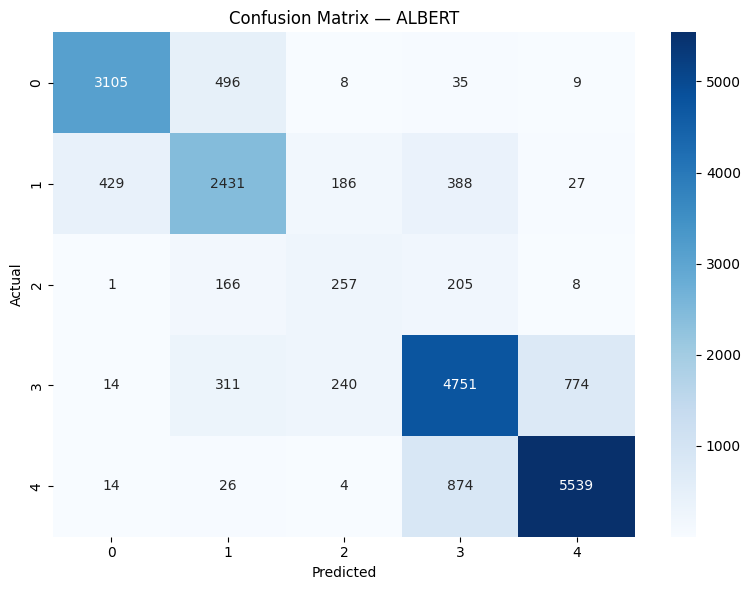

Macro AUC: 0.9483  95% CI [0.9456, 0.9507]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/ALBERT_roc_curve.png


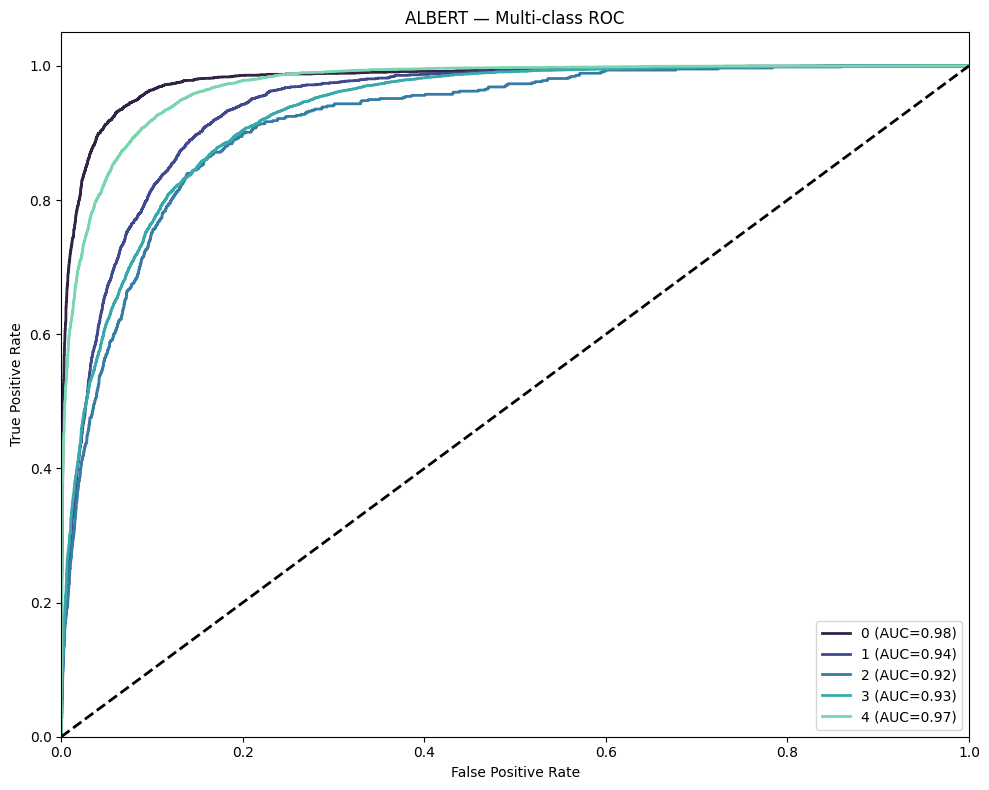

In [34]:
albert_preds, albert_probs, y_true_albert = evaluate_pytorch(
    best_albert, test_loader_albert, label_encoder, "ALBERT", use_attention_mask=True
)

### 4.4.3 BioBERT Modeling

#### Step 1: Data Preparation

In [35]:
print("\nPre-tokenizing for BioBERT...")
biobert_name = "dmis-lab/biobert-base-cased-v1.2"
biobert_tokenizer = AutoTokenizer.from_pretrained(biobert_name)

train_ids_bio, train_masks_bio = batch_tokenize(train_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_bio, val_masks_bio     = batch_tokenize(val_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_bio, test_masks_bio   = batch_tokenize(test_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
print(f"BioBERT tokens: train={train_ids_bio.shape}")

train_loader_biobert = DataLoader(
    TransformerDataset(train_ids_bio, train_masks_bio, train_labels_dl),
    shuffle=True, generator=torch.Generator().manual_seed(SEED), **_tf_loader_kw)
val_loader_biobert = DataLoader(
    TransformerDataset(val_ids_bio, val_masks_bio, val_labels_dl),
    shuffle=False, generator=torch.Generator().manual_seed(SEED + 100_000), **_tf_loader_kw)
test_loader_biobert = DataLoader(
    TransformerDataset(test_ids_bio, test_masks_bio, test_labels_dl),
    shuffle=False, generator=torch.Generator().manual_seed(SEED + 100_000), **_tf_loader_kw)


Pre-tokenizing for BioBERT...


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BioBERT tokens: train=torch.Size([60950, 200])


#### Step 2: Hyperparameter Tuning

In [36]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning BioBERT...")
    start = time.time()

    biobert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    hp_trials = []
    for _ in range(N_ITERATIONS):
        hp = {
            "lr": float(10 ** np.random.uniform(*biobert_param_space["lr"])),
            "epochs": int(np.random.randint(*biobert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*biobert_param_space["dropout"])),
        }
        hp_trials.append(hp)
    trial_log = []

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Random Search"):
        hp = dict(hp_trials[i])
        trial_seed = SEED + i
        set_seed(trial_seed)
        train_loader_biobert = DataLoader(
            TransformerDataset(train_ids_bio, train_masks_bio, train_labels_dl),
            shuffle=True, generator=torch.Generator().manual_seed(trial_seed), **_tf_loader_kw)

        config = AutoConfig.from_pretrained(
            biobert_name, num_labels=NUM_CLASSES,
            hidden_dropout_prob=hp["dropout"],
            attention_probs_dropout_prob=hp["dropout"],
            classifier_dropout=hp["dropout"],
        )
        model = AutoModelForSequenceClassification.from_pretrained(biobert_name, config=config)

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        trial_log.append({"trial": i + 1, "seed": trial_seed, "val_f1": float(f1_val),
                          **hp, **model.training_record})
        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = {**hp, "trial_seed": trial_seed}
            best_biobert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    torch.save(best_biobert.state_dict(), MODEL_PATHS["biobert"]["model"])
    pd.DataFrame(trial_log).to_csv(OUTPUT_PATH / "biobert_trial_log.csv", index=False)
    save_transformer_record(best_biobert, biobert_tokenizer, best_params_biobert, "biobert")
else:
    print("Loading BioBERT from disk...")
    config_path = OUTPUT_PATH / "biobert_config"
    saved_config = AutoConfig.from_pretrained(config_path if config_path.exists() else biobert_name, num_labels=NUM_CLASSES)
    best_biobert = AutoModelForSequenceClassification.from_pretrained(biobert_name, config=saved_config)
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))
    print(f"Loaded BioBERT from {MODEL_PATHS['biobert']['model']}")



Tuning BioBERT...


BioBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

  Epoch 1/6 | Loss=1.2415 | Val F1=0.6804
  Epoch 2/6 | Loss=0.8014 | Val F1=0.7275
  Epoch 3/6 | Loss=0.6475 | Val F1=0.7288
  Epoch 4/6 | Loss=0.5345 | Val F1=0.7511
  Epoch 5/6 | Loss=0.4627 | Val F1=0.7575
  Epoch 6/6 | Loss=0.4287 | Val F1=0.7581


BioBERT Random Search:  90%|█████████ | 9/10 [58:34<06:28, 388.81s/it]Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/9 | Loss=1.3513 | Val F1=0.6370
  Epoch 2/9 | Loss=0.8848 | Val F1=0.7289
  Epoch 3/9 | Loss=0.7396 | Val F1=0.7338
  Epoch 4/9 | Loss=0.6404 | Val F1=0.7424
  Epoch 5/9 | Loss=0.5607 | Val F1=0.7520
  Epoch 6/9 | Loss=0.4960 | Val F1=0.7562
  Epoch 7/9 | Loss=0.4489 | Val F1=0.7571
  Epoch 8/9 | Loss=0.4131 | Val F1=0.7629
  Epoch 9/9 | Loss=0.3970 | Val F1=0.7630


BioBERT Random Search: 100%|██████████| 10/10 [1:07:19<00:00, 403.94s/it]


BioBERT tuning: 4039.4s | Best F1=0.7630
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563, 'trial_seed': 2034}


#### Step 3: Model Evaluation

Eval BioBERT: 100%|██████████| 159/159 [00:04<00:00, 33.61it/s]



Evaluation: BioBERT
               precision    recall  f1-score   support

VERY_NEGATIVE     0.8439    0.8508    0.8473      3653
     NEGATIVE     0.6717    0.6651    0.6684      3461
      NEUTRAL     0.2701    0.4537    0.3386       637
     POSITIVE     0.7572    0.7186    0.7374      6090
VERY_POSITIVE     0.8587    0.8430    0.8507      6457

     accuracy                         0.7645     20298
    macro avg     0.6803    0.7062    0.6885     20298
 weighted avg     0.7752    0.7645    0.7690     20298

Weighted F1: 0.7690  95% CI [0.7636, 0.7750]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/BioBERT_confusion_matrix.png


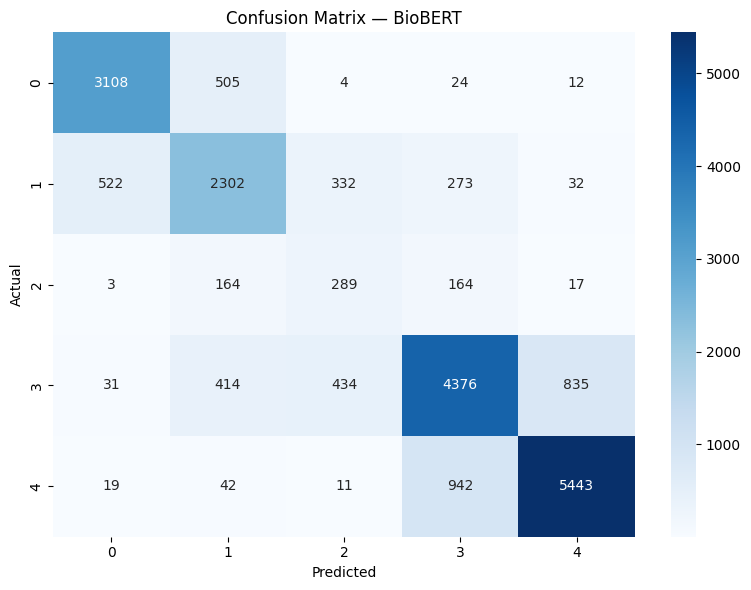

Macro AUC: 0.9426  95% CI [0.9401, 0.9449]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/BioBERT_roc_curve.png


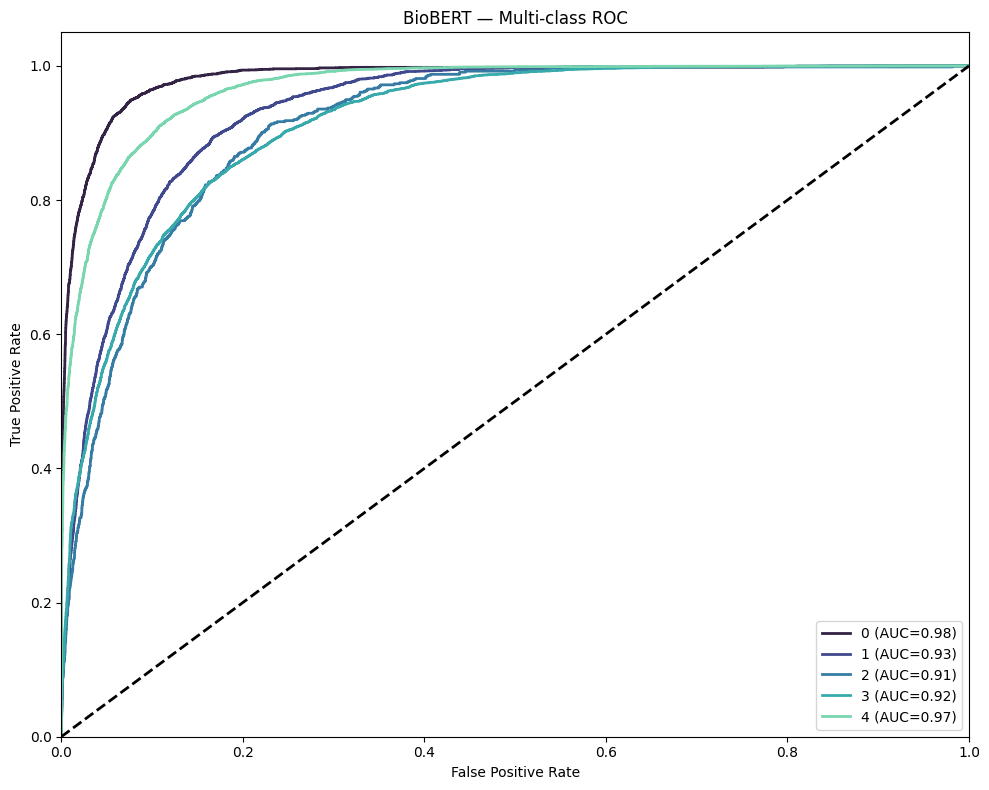

In [37]:
biobert_preds, biobert_probs, y_true_biobert = evaluate_pytorch(
    best_biobert, test_loader_biobert, label_encoder, "BioBERT", use_attention_mask=True
)

## 4.3 Save Predictions for DL models

In [38]:
print("\nSaving DL predictions...")

# Verify all DL models evaluated on same test set
assert np.array_equal(y_true_gru, y_true_cnn)
assert np.array_equal(y_true_gru, y_true_albert)
assert np.array_equal(y_true_gru, y_true_biobert)
y_true_dl = y_true_gru

true_names = label_encoder.inverse_transform(y_true_dl)

if "id" in df_test_dl.columns:
    df_pred_dl = df_test_dl[["id", TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
else:
    df_pred_dl = df_test_dl[[TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
    df_pred_dl.insert(0, "id", df_test_dl.index)

df_pred_dl = df_pred_dl.rename(columns={TEXT_COLUMN: "text", LABEL_COLUMN_ENCODED: "true_label_id"})
df_pred_dl.insert(1, ID_COLUMN, df_test_dl[ID_COLUMN].values)
df_pred_dl["true_label"] = true_names

for name, preds, probs in [
    ("gru", gru_preds, gru_probs),
    ("cnn", cnn_preds, cnn_probs),
    ("albert", albert_preds, albert_probs),
    ("biobert", biobert_preds, biobert_probs),
]:
    require_probabilities(probs, NUM_CLASSES)
    df_pred_dl[f"{name}_pred_id"] = preds
    df_pred_dl[f"{name}_pred"] = label_encoder.inverse_transform(preds)
    for i, cls in enumerate(label_encoder.classes_):
        df_pred_dl[f"{name}_prob_{cls}"] = probs[:, i]

dl_pred_path = OUTPUT_PATH / "dl_models_predictions.csv"
df_pred_dl.to_csv(dl_pred_path, index=False)
print(f"Saved DL predictions → {dl_pred_path}")

# Human-audit rows (never trained, validated or fitted on): same vocabulary, tokenizers and models.
df_audit_dl = df_clean[df_clean["split"] == "audit"].copy()
if not df_audit_dl.empty:
    audit_texts_dl  = df_audit_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
    audit_labels_dl = df_audit_dl[LABEL_COLUMN_ENCODED].tolist()

    @torch.no_grad()
    def predict_probs(model, loader, use_attention_mask):
        model.eval().to(DEVICE)
        out = []
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                if use_attention_mask:
                    o = model(input_ids=ids, attention_mask=batch["attention_mask"].to(DEVICE, non_blocking=True))
                else:
                    o = model(input_ids=ids)
            logits = o.logits if hasattr(o, "logits") else o
            require_finite_tensor(logits, "prediction logits")
            out.append(torch.softmax(logits.float(), dim=1).cpu().numpy())
        return require_probabilities(np.concatenate(out), NUM_CLASSES)

    _audit_seq = DataLoader(
        SeqDataset(build_padded_sequences(audit_texts_dl, word_to_index), torch.tensor(audit_labels_dl, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=False)
    _audit_loaders = {"gru": (best_gru, _audit_seq, False), "cnn": (best_cnn, _audit_seq, False)}
    for _name, _model, _tok in [("albert", best_albert, albert_tokenizer), ("biobert", best_biobert, biobert_tokenizer)]:
        _ids, _masks = batch_tokenize(audit_texts_dl, _tok, MAX_TOKEN_LENGTH)
        _audit_loaders[_name] = (_model, DataLoader(TransformerDataset(_ids, _masks, audit_labels_dl),
                                                    batch_size=BATCH_SIZE, shuffle=False), True)

    df_pred_dl_audit = df_audit_dl[[ID_COLUMN, "narrative_group", "is_human_annotated", "audit_stratum"]].copy()
    df_pred_dl_audit["true_label_id"] = audit_labels_dl
    df_pred_dl_audit["true_label"]    = label_encoder.inverse_transform(audit_labels_dl)
    for _name, (_model, _loader, _mask) in _audit_loaders.items():
        _probs = predict_probs(_model, _loader, _mask)
        df_pred_dl_audit[f"{_name}_pred_id"] = _probs.argmax(axis=1)
        df_pred_dl_audit[f"{_name}_pred"]    = label_encoder.inverse_transform(_probs.argmax(axis=1))
        for _i, _cls in enumerate(label_encoder.classes_):
            df_pred_dl_audit[f"{_name}_prob_{_cls}"] = _probs[:, _i]

    _path = OUTPUT_PATH / "dl_models_predictions_audit.csv"
    df_pred_dl_audit.to_csv(_path, index=False)
    print(f"Audit rows: {len(df_pred_dl_audit)} ({int(df_pred_dl_audit['is_human_annotated'].sum())} human-annotated) → {_path}")


Saving DL predictions...
Saved DL predictions → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/dl_models_predictions.csv
Audit rows: 557 (500 human-annotated) → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/dl_models_predictions_audit.csv


# 5. Model Comparison

In [39]:
print("\n" + "="*60)
print("MODEL COMPARISON — McNemar Pairwise Tests")
print("="*60)

# Load both prediction files
df_ml_pred = pd.read_csv(OUTPUT_PATH / "ml_models_predictions.csv")
df_dl_pred = pd.read_csv(OUTPUT_PATH / "dl_models_predictions.csv")

# Join on the stable review ID only; reference labels are compared afterwards, not used as keys.
df_merged = pd.merge(df_ml_pred, df_dl_pred, on=ID_COLUMN, suffixes=("_ml", "_dl"), validate="one_to_one")
assert len(df_merged) == len(df_ml_pred) == len(df_dl_pred), "ML and DL prediction files cover different reviews"
assert (df_merged["true_label_id_ml"] == df_merged["true_label_id_dl"]).all(), "reference labels differ between files"
df_merged["true_label_id"] = df_merged["true_label_id_ml"]
print(f"Merged: {df_merged.shape[0]} rows")
# McNemar compares paired correct/incorrect decisions and treats reviews as independent; about 10% of
# rows share a narrative, so the narrative-cluster paired intervals of Section 7 are the primary comparison.

y_true_all = df_merged["true_label_id"].values

# Build prediction dict
model_preds_all = {
    "LR":     label_encoder.transform(df_merged["lr_pred"].values),
    "RF":     label_encoder.transform(df_merged["rf_pred"].values),
    "LGBM":   label_encoder.transform(df_merged["lgbm_pred"].values),
    "GRU":    df_merged["gru_pred_id"].values,
    "CNN":    df_merged["cnn_pred_id"].values,
    "ALBERT": df_merged["albert_pred_id"].values,
    "BioBERT": df_merged["biobert_pred_id"].values,
}

# Verify lengths
for name, arr in model_preds_all.items():
    assert len(arr) == len(y_true_all), f"{name} length mismatch"


def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(names, 2):
        y1, y2 = np.asarray(model_preds[m1]), np.asarray(model_preds[m2])
        c1 = (y1 == y_true)
        c2 = (y2 == y_true)

        a = np.sum(c1 & c2)
        b = np.sum(c1 & ~c2)
        c = np.sum(~c1 & c2)
        d = np.sum(~c1 & ~c2)

        if b + c == 0:
            statistic, p = 0.0, 1.0
        else:
            res = mcnemar(np.array([[a, b], [c, d]]), exact=False, correction=True)
            statistic, p = float(res.statistic), float(res.pvalue)

        if p >= 0.05:
            winner = "Inconclusive"
        elif b > c:
            winner = f"{m1} > {m2}"
        elif c > b:
            winner = f"{m2} > {m1}"
        else:
            winner = "Tie"

        results.append({
            "Model_1": m1, "Model_2": m2,
            "both_correct": a, "m1_only": b, "m2_only": c, "both_wrong": d,
            "statistic": statistic, "p_raw": p, "winner_raw": winner,
        })

    raw_p = [r["p_raw"] for r in results]
    _, corrected_p, _, _ = multipletests(raw_p, method=method)

    for i, pc in enumerate(corrected_p):
        results[i]["p_corrected"] = pc
        results[i]["significant"] = "Yes" if pc < 0.05 else "No"

    df_res = pd.DataFrame(results)
    print(f"\nPairwise McNemar Tests (corrected: {method}):")
    print(df_res.to_string(index=False))
    return df_res


df_mcnemar = mcnemar_pairwise(y_true_all, model_preds_all)

# Save
mcnemar_path = OUTPUT_PATH / "mcnemar_results.csv"
df_mcnemar.to_csv(mcnemar_path, index=False)
print(f"\nSaved McNemar results → {mcnemar_path}")

print("\n✓ Pipeline complete.")


MODEL COMPARISON — McNemar Pairwise Tests
Merged: 20298 rows

Pairwise McNemar Tests (corrected: bonferroni):
Model_1 Model_2  both_correct  m1_only  m2_only  both_wrong   statistic         p_raw       winner_raw   p_corrected significant
     LR      RF          9323     3046     1964        5965  233.245709  1.168231e-52          LR > RF  2.453285e-51         Yes
     LR    LGBM         10119     2250     1874        6055   34.099176  5.237345e-09        LR > LGBM  1.099842e-07         Yes
     LR     GRU          9692     2677     3546        4383  121.070866  3.687226e-28         GRU > LR  7.743175e-27         Yes
     LR     CNN         10087     2282     3082        4847  119.015846  1.038962e-27         CNN > LR  2.181820e-26         Yes
     LR  ALBERT         10793     1576     5290        2639 2007.918584  0.000000e+00      ALBERT > LR  0.000000e+00         Yes
     LR BioBERT         10519     1850     4999        2930 1446.912542  0.000000e+00     BioBERT > LR  0.000000e+0

# 6. Add Additional Metric: MAE \& QWK

In [40]:
# ============================================================
# Ordinal metrics for this notebook:
# MAE and Quadratic Weighted Kappa (QWK)
# with 95% bootstrap CI, 1000 bootstrap samples
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import cohen_kappa_score

N_BOOT = 1000
BOOT_SEED = 20260510

OUTPUT_PATH = Path(OUTPUT_PATH)

PREDICTION_FILES = [
    OUTPUT_PATH / "ml_models_predictions.csv",
    OUTPUT_PATH / "dl_models_predictions.csv",
]

# Explicit ordinal mapping from your notebook config
LABEL_TO_ID = {label: i for i, label in enumerate(CLASS_NAMES)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

def to_ordinal_array(x):
    s = pd.Series(x)

    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float).astype(int).to_numpy()

    z = s.astype(str).str.strip().str.upper()
    mapped = z.map(LABEL_TO_ID)

    if mapped.isna().any():
        bad = sorted(z[mapped.isna()].dropna().unique().tolist())[:20]
        raise ValueError(f"Unmapped label values: {bad}")

    return mapped.astype(int).to_numpy()

def mae_score(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def qwk_score(y_true, y_pred):
    labels = np.arange(len(CLASS_NAMES))
    return float(cohen_kappa_score(y_true, y_pred, labels=labels, weights="quadratic"))

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, seed=20260510):
    rng = np.random.default_rng(seed)
    n = len(y_true)

    point = metric_fn(y_true, y_pred)
    boot = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[b] = metric_fn(y_true[idx], y_pred[idx])

    lo, hi = np.nanpercentile(boot, [2.5, 97.5])
    return point, float(lo), float(hi)

def get_true_column(df):
    if "true_label_id" in df.columns:
        return "true_label_id"
    if "true_label" in df.columns:
        return "true_label"
    raise ValueError("Could not find true-label column. Expected true_label_id or true_label.")

def get_prediction_columns(df):
    # ML: lr_pred, rf_pred, lgbm_pred
    # DL: gru_pred, cnn_pred, albert_pred, biobert_pred
    return [
        c for c in df.columns
        if c.endswith("_pred") and not c.endswith("_pred_id")
    ]

rows = []

for pred_path in PREDICTION_FILES:
    if not pred_path.exists():
        print(f"Skipping missing file: {pred_path}")
        continue

    print(f"Reading: {pred_path}")
    df_pred = pd.read_csv(pred_path)

    true_col = get_true_column(df_pred)
    y_true = to_ordinal_array(df_pred[true_col])

    pred_cols = get_prediction_columns(df_pred)
    if not pred_cols:
        raise ValueError(f"No prediction columns ending in _pred found in {pred_path}")

    for pred_col in pred_cols:
        y_pred = to_ordinal_array(df_pred[pred_col])
        model = pred_col.replace("_pred", "")

        mae, mae_lo, mae_hi = bootstrap_ci(
            y_true,
            y_pred,
            mae_score,
            n_boot=N_BOOT,
            seed=BOOT_SEED,
        )

        qwk, qwk_lo, qwk_hi = bootstrap_ci(
            y_true,
            y_pred,
            qwk_score,
            n_boot=N_BOOT,
            seed=BOOT_SEED + 17,
        )

        rows.append({
            "prediction_file": pred_path.name,
            "model": model,
            "n": len(df_pred),
            "mae": mae,
            "mae_ci_lower": mae_lo,
            "mae_ci_upper": mae_hi,
            "qwk": qwk,
            "qwk_ci_lower": qwk_lo,
            "qwk_ci_upper": qwk_hi,
        })

ordinal_metrics = pd.DataFrame(rows)

display(ordinal_metrics)

save_path = OUTPUT_PATH / "ordinal_mae_qwk_bootstrap.csv"
ordinal_metrics.to_csv(save_path, index=False)
print(f"Saved: {save_path}")


Reading: /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/ml_models_predictions.csv
Reading: /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/dl_models_predictions.csv


,prediction_file,model,n,mae,mae_ci_lower,mae_ci_upper,qwk,qwk_ci_lower,qwk_ci_upper
0,ml_models_predictions.csv,lr,20298,0.641689,0.627550,0.654254,0.705011,0.694848,0.713836
1,ml_models_predictions.csv,rf,20298,0.792590,0.778105,0.807424,0.609302,0.598432,0.620381
2,ml_models_predictions.csv,lgbm,20298,0.672135,0.657945,0.684847,0.697923,0.688982,0.707076
3,dl_models_predictions.csv,gru,20298,0.493842,0.483101,0.504486,0.808058,0.801294,0.814484
4,dl_models_predictions.csv,cnn,20298,0.538181,0.525913,0.549512,0.771365,0.763557,0.778606
5,dl_models_predictions.csv,albert,20298,0.256577,0.249134,0.264558,0.918554,0.915287,0.922052
6,dl_models_predictions.csv,biobert,20298,0.288354,0.280964,0.296091,0.909278,0.905418,0.913084


Saved: /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_4ominiLabel_aug/outputs/ordinal_mae_qwk_bootstrap.csv


# 7. Reported Metrics Summary

In [41]:
# ============================================================
# Every metric reported in the manuscript, for every model trained in this notebook,
# from the saved test predictions. Point estimates are computed on the actual test set;
# 95% intervals come from ONE set of narrative-cluster bootstrap resamples shared by all models and
# metrics (audit rows are not part of this table; they are in the *_audit.csv prediction files).
#   weighted precision / recall / F1, macro F1, micro F1 (= accuracy), macro one-vs-rest AUC,
#   MAE on the 0–4 ordinal scale, quadratic weighted kappa
# ============================================================
from sklearn.metrics import precision_score, recall_score, cohen_kappa_score

N_BOOT_SUMMARY = 1000
_label_to_id = {c: i for i, c in enumerate(CLASS_NAMES)}
_labels = list(range(NUM_CLASSES))

def _metric_values(y, p, prob):
    out = {
        "precision_w": precision_score(y, p, average="weighted", labels=_labels, zero_division=0),
        "recall_w":    recall_score(y, p, average="weighted", labels=_labels, zero_division=0),
        "f1_weighted": f1_score(y, p, average="weighted", labels=_labels, zero_division=0),
        "f1_macro":    f1_score(y, p, average="macro", labels=_labels, zero_division=0),
        "f1_micro":    f1_score(y, p, average="micro", labels=_labels, zero_division=0),
        "mae":         float(np.mean(np.abs(y - p))),
        "qwk":         cohen_kappa_score(y, p, labels=_labels, weights="quadratic"),
    }
    try:
        out["auc_macro"] = roc_auc_score(y, prob, average="macro", multi_class="ovr", labels=_labels)
    except ValueError:                       # a resample without one of the classes
        out["auc_macro"] = np.nan
    return out

# Resampling unit = the narrative (rows that share a review text stay together), and every model
# and every metric uses the SAME resamples, so differences between models are paired.
_groups_by_id = dict(zip(df_clean[ID_COLUMN], df_clean["narrative_group"]))

def _group_resamples(group_ids, n_boot, seed=20260919):
    codes, _ = pd.factorize(pd.Series(group_ids))
    members = [np.flatnonzero(codes == g) for g in range(codes.max() + 1)]
    rng = np.random.default_rng(seed)
    for _ in range(n_boot):
        draw = rng.integers(0, len(members), len(members))
        yield np.concatenate([members[g] for g in draw])

_preds = {}                                        # model -> (y, pred, prob), all on the same test rows
_ref = None
for _file in ["ml_models_predictions.csv", "dl_models_predictions.csv"]:
    if not (OUTPUT_PATH / _file).exists():
        print(f"Skipping missing file: {_file}")
        continue
    _df = pd.read_csv(OUTPUT_PATH / _file).sort_values(ID_COLUMN).reset_index(drop=True)
    assert _df[ID_COLUMN].is_unique
    if _ref is None:
        _ref = _df[[ID_COLUMN, "true_label_id"]].copy()
    else:                                          # same reviews, same reference labels in both files
        assert _df[ID_COLUMN].equals(_ref[ID_COLUMN]) and _df["true_label_id"].equals(_ref["true_label_id"])
    for _m in ["lr", "rf", "lgbm", "gru", "cnn", "albert", "biobert"]:
        if f"{_m}_pred" not in _df.columns:
            continue
        _p = _df[f"{_m}_pred"].astype(str).str.upper().map(_label_to_id).to_numpy().astype(int)
        _prob = _df[[f"{_m}_prob_{c}" for c in CLASS_NAMES]].to_numpy()
        _preds[_m] = (_p, _prob / _prob.sum(axis=1, keepdims=True))

_y = _ref["true_label_id"].to_numpy().astype(int)
_test_groups = _ref[ID_COLUMN].map(_groups_by_id).to_numpy()
assert not pd.isna(_test_groups).any()
_resamples = list(_group_resamples(_test_groups, N_BOOT_SUMMARY))

point = {m: _metric_values(_y, p, prob) for m, (p, prob) in _preds.items()}
boot = {m: {k: [] for k in point[m]} for m in _preds}
for idx in tqdm(_resamples, desc="Narrative-cluster bootstrap"):
    for m, (p, prob) in _preds.items():
        for k, v in _metric_values(_y[idx], p[idx], prob[idx]).items():
            boot[m][k].append(v)

summary_rows = []
for m in _preds:
    row = {"model": m, "n_test": len(_y), "n_narratives": int(pd.Series(_test_groups).nunique())}
    for k, v in point[m].items():
        lo, hi = np.nanpercentile(boot[m][k], [2.5, 97.5])
        row[k], row[f"{k}_lo"], row[f"{k}_hi"] = v, lo, hi
    summary_rows.append(row)

# Paired differences between models (same resamples): the primary comparison between models.
diff_rows = []
for m1, m2 in combinations(list(_preds), 2):
    for k in ["f1_weighted", "f1_macro", "qwk", "mae"]:
        d = np.asarray(boot[m1][k]) - np.asarray(boot[m2][k])
        lo, hi = np.nanpercentile(d, [2.5, 97.5])
        diff_rows.append({"model_1": m1, "model_2": m2, "metric": k, "diff": point[m1][k] - point[m2][k],
                          "diff_lo": lo, "diff_hi": hi, "interval_excludes_0": bool(lo > 0 or hi < 0)})
paired_differences = pd.DataFrame(diff_rows)
paired_differences.to_csv(OUTPUT_PATH / "paired_differences_bootstrap.csv", index=False)

reported_metrics = pd.DataFrame(summary_rows)
_path = OUTPUT_PATH / "reported_metrics_bootstrap.csv"
reported_metrics.to_csv(_path, index=False)

def _cell(r, k):
    return f"{r[k]:.3f} ({r[k + '_lo']:.3f}, {r[k + '_hi']:.3f})"

print(f"{LABEL_COLUMN} | {'text + metadata' if 'TEXT_COLUMN0' in globals() else 'text only'} | test n = {len(_y)}")
print(pd.DataFrame({
    "Model": reported_metrics["model"].str.upper(),
    "Precision": reported_metrics["precision_w"].map("{:.3f}".format),
    "Recall": reported_metrics["recall_w"].map("{:.3f}".format),
    "Weighted F1 (95% CI)": [_cell(r, "f1_weighted") for _, r in reported_metrics.iterrows()],
    "Macro F1 (95% CI)": [_cell(r, "f1_macro") for _, r in reported_metrics.iterrows()],
    "Micro F1 (95% CI)": [_cell(r, "f1_micro") for _, r in reported_metrics.iterrows()],
    "AUC (95% CI)": [_cell(r, "auc_macro") for _, r in reported_metrics.iterrows()],
    "MAE (95% CI)": [_cell(r, "mae") for _, r in reported_metrics.iterrows()],
    "QWK (95% CI)": [_cell(r, "qwk") for _, r in reported_metrics.iterrows()],
}).to_string(index=False))
print(f"\nSaved → {_path}")

print("\nPaired differences in weighted F1 (model_1 − model_2, 95% narrative-cluster interval):")
print(paired_differences[paired_differences["metric"] == "f1_weighted"].round(4).to_string(index=False))


Narrative-cluster bootstrap: 100%|██████████| 1000/1000 [02:05<00:00,  8.00it/s]

ai_sent5_hard | text + metadata | test n = 20298
  Model Precision Recall Weighted F1 (95% CI)    Macro F1 (95% CI)    Micro F1 (95% CI)         AUC (95% CI)         MAE (95% CI)         QWK (95% CI)
     LR     0.591  0.609 0.595 (0.588, 0.603) 0.481 (0.474, 0.488) 0.609 (0.602, 0.617) 0.834 (0.830, 0.839) 0.642 (0.628, 0.656) 0.705 (0.695, 0.714)
     RF     0.533  0.556 0.533 (0.525, 0.541) 0.425 (0.418, 0.431) 0.556 (0.548, 0.564) 0.790 (0.784, 0.795) 0.793 (0.778, 0.808) 0.609 (0.598, 0.620)
   LGBM     0.586  0.591 0.588 (0.580, 0.595) 0.497 (0.489, 0.505) 0.591 (0.583, 0.598) 0.826 (0.821, 0.831) 0.672 (0.658, 0.687) 0.698 (0.688, 0.707)
    GRU     0.658  0.652 0.655 (0.648, 0.662) 0.561 (0.553, 0.569) 0.652 (0.645, 0.660) 0.875 (0.871, 0.879) 0.494 (0.483, 0.506) 0.808 (0.801, 0.815)
    CNN     0.645  0.649 0.645 (0.638, 0.652) 0.544 (0.536, 0.552) 0.649 (0.642, 0.655) 0.871 (0.867, 0.875) 0.538 (0.526, 0.552) 0.771 (0.763, 0.779)
 ALBERT     0.794  0.792 0.793 (0.788, 0.799)